# 02477 Exercise 3: Bayesian Linear regression

In [1]:
%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
from scipy.stats import multivariate_normal
import jax


snb.set_theme(font_scale=1.25)

- Rev. 3.3, 17/2-25

### Overview

The purpose of this exercise is to become familiar with Bayesian linear regression and reinforce the basic concepts of Bayesian inference. 
In the exercise, you will implement several parts of Bayesian linear regression pipeline. However, remember that the purpose of the exercise is to study and understand the key equations for Bayesian linear regression as well as to learn how to use them. 
Besides being useful for practical purposes, the code also allows you to build intuition, e.g. by investigating what happens when you change different parameters etc. So think of the code as a tool for understanding the models and their key equations and not only as an end-product.

**Content**

- Part 1: Visualizing the prior, likelihood and posterior
- Part 2: Implementing the posterior distribution
- Part 3: The posterior predictive distribution
- Part 4: Modelling the number of Airline passengers





**Note**: The exercise contains several **discussion questions**, which are questions, where are supposed to actively experiment with the code and/or reason with the equations to arrive at the relevant conclusions. This also means that we won't provide a specific solution for this task. However, you are more than welcome to check your understanding and your conclusions with the TAs. Instead of proving the full description for every discussion question, we simply tag it with: [**Discussion question**] after the question.



# Bayesian Linear Regression – Extended Notes

*These notes expand the standard derivation with extra signposts, shape hints, and intuitive remarks so you always know **what lives where** and **why every term appears**.*

---

## 1  Problem set‑up, shapes first 👀

| symbol                             | description                                                                            | shape                            |
| ---------------------------------- | -------------------------------------------------------------------------------------- | -------------------------------- |
| $N$                              | number of observations                                                                 | –                                |
| $D$                              | number of features (incl. bias)                                                        | –                                |
| $\mathbf{y}$                     | response vector                                                                        | $\mathbb{R}^{N\times1}$        |
| $\mathbf{x}\_n$                  | raw covariate                                                                          | $\mathbb{R}^p$ (ignored below) |
| $\boldsymbol\phi(\mathbf{x}\_n)$ | feature map                                                                            | $\mathbb{R}^{D\times1}$        |
| $\mathbf\Phi$                    | **design matrix** $(\phi(\mathbf{x}\_1)^{!\top};\ldots;\phi(\mathbf{x}\_N)^{!\top})$ | $\mathbb{R}^{N\times D}$       |
| $\mathbf w$                      | weight vector                                                                          | $\mathbb{R}^{D\times1}$        |
| $\beta =  \sigma^{-2}$            | noise precision                                                                        | scalar                           |

With that convention the linear‑Gaussian model is

$$
\mathbf{y} \;=\; \boldsymbol{\Phi}\,\mathbf{w}\;+\;\mathbf{e},
\qquad
\mathbf{e}\;\sim\;\mathcal{N}\!\bigl(\mathbf{0},\,\beta^{-1}\mathbf{I}\bigr)
$$

> **Why shapes first?** Writing them down once prevents every transpose error later.

---

## 2  Maximum-likelihood baseline (why Bayes?)

$$
\hat{\mathbf{w}}_{\text{MLE}} =
\left( \boldsymbol{\Phi}^\top \boldsymbol{\Phi} \right)^{-1}
\boldsymbol{\Phi}^\top \mathbf{y}
$$

- ✔️ Closed form  
- ✘ Ignores prior; can explode when $D \approx N$ or $\boldsymbol{\Phi}^\top \boldsymbol{\Phi}$ is ill-conditioned.

**MLE for $\sigma$ (Gaussian-noise linear regression $\mathbf{y}\mid\mathbf{w}\sim\mathcal{N}(\boldsymbol{\Phi}\mathbf{w}, \sigma^2\mathbf{I})$):**

$$
\hat{\sigma}^2_{\text{MLE}} = \frac{1}{N}\,\|\mathbf{y}-\boldsymbol{\Phi}\,\hat{\mathbf{w}}_{\text{MLE}}\|_2^2
$$

$$
\hat{\sigma}_{\text{MLE}} = \sqrt{\frac{1}{N}\,\|\mathbf{y}-\boldsymbol{\Phi}\,\hat{\mathbf{w}}_{\text{MLE}}\|_2^2}
$$

> Note: The unbiased variance estimate uses \(N-D\) instead of \(N\).


---

## 2.1 MAP estimate (ridge solution)

With a Gaussian prior  
$p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, \alpha^{-1} \mathbf{I})$  
and Gaussian likelihood, the MAP solution is:

$$
\hat{\mathbf{w}}_{\text{MAP}} =
\left( \beta \boldsymbol{\Phi}^\top \boldsymbol{\Phi} + \alpha \mathbf{I} \right)^{-1}
\beta \boldsymbol{\Phi}^\top \mathbf{y}
$$

* ✔️ Closed form   ✔️ Regularised solution  
* Equivalent to ridge regression with $\lambda = \alpha / \beta$

---

## 3  Prior + likelihood ⇒ joint

Choose an **isotropic Gaussian prior**

$\mathbf w \sim \mathcal N(\mathbf m_0,\;\mathbf S_0).$

> ##### Notation card 📎
>
> * $\mathbf{m}_0$ — prior mean (often $\mathbf{0}$)  
> * $\mathbf{S}_0$ — prior covariance (often $\alpha^{-1}\mathbf{I}$)  
> * $\alpha$ — weight precision ($\alpha = \mathbf{S}_0^{-1}$ if isotropic)  
> * $\beta$ — noise precision ($\beta = \sigma^{-2}$)

Joint distribution:

$$
\boxed{p(\mathbf y,\mathbf w)=\mathcal N(\mathbf y\mid\mathbf\Phi\mathbf w,\,\beta^{-1}\mathbf I)\;\mathcal N(\mathbf w\mid\mathbf m_0,\,\mathbf S_0).}
$$
> **Conjugacy in one line:** Gaussian prior × Gaussian likelihood with a **linear link**  
> $\mathbf{w} \to \mathbf{y} \;\Rightarrow\; \text{posterior stays Gaussian.}$


---

## 4  Posterior derivation – *completion of the square (sketch)*
Write the exponent of the joint density and collect all terms in $\mathbf{w}$:


$$
-\tfrac12\left\{(\mathbf w-\mathbf m_0)^{\!\top}\!\mathbf S_0^{\!-1}(\mathbf w-\mathbf m_0) + \beta\|\mathbf y-\mathbf\Phi\mathbf w\|^2 \right\}.
$$

Group quadratic, linear, constant ⇒ identify

$$
\boxed{\mathbf S^{-1}=\mathbf S_0^{\!-1}+\beta\mathbf\Phi^{\!\top}\mathbf\Phi},\qquad
\boxed{\mathbf m=\beta\,\mathbf S\,\mathbf\Phi^{\!\top}\mathbf y}.\tag{1–2}
$$

Everything else is “just constants”.

---

## 5  Links to ridge regression

*If $\mathbf{S}_0 = \alpha^{-1} \mathbf{I}$ and $\mathbf{m}_0 = \mathbf{0}$,  maximising the posterior is ridge regression with penalty $\lambda = \alpha / \beta$.*

---

## 6  Posterior‑predictive distribution

For a new input $x^*$ with $\boldsymbol{\phi}_* = \boldsymbol{\phi}(x^*)$:

$$
\begin{aligned}
 p(f^*\mid\mathbf y) &= \mathcal N\bigl(f^*\mid \mathbf m^{\!\top}\boldsymbol\phi_*,\; \boldsymbol\phi_*^{\!\top}\mathbf S\boldsymbol\phi_*\bigr),\\[4pt]
 p(y^*\mid\mathbf y) &= \mathcal N\bigl(y^*\mid \mathbf m^{\!\top}\boldsymbol\phi_*,\; \boldsymbol\phi_*^{\!\top}\mathbf S\boldsymbol\phi_* + \beta^{-1}\bigr).
\end{aligned}
$$

> *mean = best guess,  projection term = parameter uncertainty,  $\beta^{-1}$ = sensor noise*

---

## 7  Estimator zoo (where we now stand)

| Flavour                    | Treats $(\alpha,\beta)$ as                                 | Integrates $\mathbf{w}$? | Risk of over-/under-fit |
|---------------------------|-------------------------------------------------------------|---------------------------|-------------------------|
| **MLE**                   | fixed, $\alpha = 0$                                         | no                        | high (over-fit)        |
| **MAP**                   | fixed finite $\alpha, \beta$                                | no                        | moderate                |
| **Evidence (emp. Bayes)** | learned by maximising $\log p(\mathbf{y} \mid \alpha, \beta)$ | no                        | lower                   |
| **Full Bayes**            | has priors, *integrates* $(\alpha, \beta)$ too              | yes                       | lowest, but costly      |

(We are at the bold row—posterior given fixed $\alpha,\beta$ ready to move to evidence optimisation.)

---


## 8 From posterior **over w** to posterior **over future data**

> *This section mirrors the structure you have just seen for the weight posterior,  
>  but now the random variable we care about is a **new target value** \(y^*\).  
>  Follow the three‑row table and you will never lose track of what each symbol means.*

| Symbol | “Lives in”     | Role                          |
|--------|----------------|-------------------------------|
| $x^*$  | $\mathbb{R}$   | new input location            |
| $\boldsymbol{\phi}_* = \begin{bmatrix} 1 \\ x^* \end{bmatrix}$ | $\mathbb{R}^{2 \times 1}$ | basis vector at $x^*$     |
| $f^* = \boldsymbol{\phi}_*^\top \mathbf{w}$ | $\mathbb{R}$   | latent noise-free prediction |
| $y^* = f^* + \varepsilon,\; \varepsilon \sim \mathcal{N}(0, \beta^{-1})$ | $\mathbb{R}$ | observable at $x^*$         |


### 8.1 Posterior over \(w\) (recap)

$$
p(\mathbf{w} \mid \mathbf{y}) = \mathcal{N}(\mathbf{w} \mid \mathbf{m}, \mathbf{S}),
\quad\;\;
\mathbf{S}^{-1} = \alpha \mathbf{I} + \beta \boldsymbol{\Phi}^\top \boldsymbol{\Phi},
\quad
\mathbf{m} = \beta \mathbf{S} \boldsymbol{\Phi}^\top \mathbf{y}.
$$

*(Shapes: $\mathbf{m}, \mathbf{w} \in \mathbb{R}^{2 \times 1}$, $\mathbf{S} \in \mathbb{R}^{2 \times 2}$.)*

---

### 8.2 Posterior predictive distribution (one-liner derivation)

Gaussian in **w** + linear map + independent Gaussian noise ⇒ **Gaussian again**:

$$
\boxed{
p(y^* \mid \mathbf{y}, x^*) 
= \mathcal{N}\!\left(y^* \mid 
\underbrace{\mathbf{m}^\top \boldsymbol{\phi}_*}_{\text{mean}},\;
\underbrace{\boldsymbol{\phi}_*^\top \mathbf{S} \boldsymbol{\phi}_*}_{\text{epistemic}} 
+\;
\underbrace{\beta^{-1}}_{\text{aleatoric}} \right)
}
$$

* • **Mean** = plug posterior-mean weights into the linear model  
* • **Epistemic variance** = uncertainty about the weights projected onto $x^*$  
* • **Aleatoric variance** = irreducible sensor noise $1/\beta$

> **Mnemonic:** ★ model uncertainty shrinks with data (first term) + ★ noise never shrinks (second term).

---
### 8.3 Worked micro‑example 📝

Take the tiny line-fitting problem:

$$
y_n = a + b x_n + e_n, \qquad
\mathbf{w} = \begin{bmatrix} a \\ b \end{bmatrix},\;
\boldsymbol{\Phi} = 
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_N
\end{bmatrix}.
$$

Assume:

- prior: $p(\mathbf{w}) = \mathcal{N}(\mathbf{0}, \alpha^{-1} \mathbf{I})$ with $\alpha = 1$  
- noise: $\beta = 5$ (i.e. $\sigma^2 = 0.2$)

Suppose after observing the data you obtain:

$$
\mathbf{m} = \begin{bmatrix} 0.8 \\ 0.6 \end{bmatrix},
\quad
\mathbf{S} = \begin{bmatrix} 0.10 & 0.02 \\ 0.02 & 0.15 \end{bmatrix}.
$$

Predict at $x^* = 1.5$:

1. **Construct basis**: $\boldsymbol{\phi}_* = [1,\,1.5]^\top$
2. **Mean**: $\mathbf{m}^\top \boldsymbol{\phi}_* = 0.8 + 0.6 \cdot 1.5 = 1.7$
3. **Epistemic variance**:  
   $\boldsymbol{\phi}_*^\top \mathbf{S} \boldsymbol{\phi}_* =
   [1,\,1.5]
   \begin{bmatrix}
   0.10 & 0.02 \\
   0.02 & 0.15
   \end{bmatrix}
   \begin{bmatrix}
   1 \\
   1.5
   \end{bmatrix}
   = 0.3425$
4. **Total variance**: $0.3425 + \beta^{-1} = 0.3425 + 0.20 = 0.543$

Hence:

$$
y^* \mid \mathbf{y}, x^* \sim \mathcal{N}(1.7,\; 0.543)
$$

~ One-standard-deviation band ≈ $1.7 \pm 0.74$

---

### 8.4 Why this matters

* **Predictions with error bars** require *both* posterior mean and posterior covariance.  
* The formula decomposes uncertainty, letting you answer questions like  
  “Will more data help or is the sensor noise the limiting factor?”  
* In active learning you pick $x^*$ that maximises the epistemic term  
  $\boldsymbol{\phi}_*^\top \mathbf{S} \boldsymbol{\phi}_*$.

---

### 8.5 Quick look ahead

If we later **learn** $\alpha, \beta$ by evidence maximisation,

* replace them by $(\hat{\alpha}, \hat{\beta})$ in $\mathbf{S}^{-1}$  
* everything else stays identical.

That is why getting comfortable with the boxed predictive Gaussian is the key step:  
once it’s clear, hyper-parameter learning is “just” a loop that sharpens $\mathbf{S}$  
and rescales the noise term.

____


### Bayesian linear regression

Linear regression is perhaps the most common technique in applied statistics and machine learning for modelling the relationship between set of a covariates $\left\lbrace \mathbf{x}_n \right\rbrace_{n=1}^N$ and a response variable $\left\lbrace y_n \right\rbrace_{n=1}^N$. Rather than modelling the relationship between $\mathbf{x}_n$ and $y_n$ directly, we often apply a transformation $\phi$ to the input vectors $\mathbf{x}_n$ first. That is, we often use $\mathbf{\phi}_n = \mathbf{\phi}(\mathbf{x}_n)$ as input to regression model rather than $\mathbf{x}_n$ directly:

\begin{align*}
y_n = f(\mathbf{x}_n) + e_n = \phi(\mathbf{x}_n)^T \mathbf{w} + e_n = \mathbf{\phi}_n^T \mathbf{w} + e_n,
\end{align*}

where $f(\mathbf{x_n}) \equiv \mathbf{\phi}_n^T \mathbf{w}$.


More generally, let $\mathbf{\Phi} \in \mathbb{R}^{N \times D}$ be a **design matrix** and let  $\mathbf{y} \in \mathbb{R}^N$ be the response variables, then the linear regression model is given by

\begin{align*}
\mathbf{y}= \mathbf{\Phi}\mathbf{w} + \mathbf{e},
\end{align*}


where $\mathbf{w} \in \mathbb{R}^D$ is the regression weights and $\mathbf{e} \in \mathbb{R}^N$ is a noise vector. In this exercise, we will only look at additive isotropic Gaussian noise models, i.e. $e_n \sim \mathcal{N}(0, \sigma^2)$, but later we will study more general set-ups. Recall, the **maximum likelihood estimator** of the weights $\mathbf{w}$ is given by

\begin{align*}
\hat{\mathbf{w}}_{\text{MLE}} = \left(\mathbf{\Phi}^T \mathbf{\Phi}\right)^{-1} \mathbf{\Phi}^T \mathbf{y}
\end{align*}

We will now turn to the Bayesian treatment. Assuming isotropic Gaussian noise and imposing a multivariate Gaussian prior on $\mathbf{w} \sim \mathcal{N}\left(\mathbf{m}_0, \mathbf{S}_0\right)$ gives rise to the following joint distribution

\begin{align*}
p(\mathbf{y}, \mathbf{w}) = p\left(\mathbf{y}|\mathbf{w}\right)p\left(\mathbf{w}\right) = \mathcal{N}\left(\mathbf{y}\big|\mathbf{\Phi}\mathbf{w}, \sigma^2\mathbf{I}\right)\mathcal{N}\left(\mathbf{w}\big|\mathbf{m}_0, \mathbf{S}_0\right),
\end{align*}

where $\sigma^2$ is the noise variance. We will follow Bishop's notation and use the **noise precision** $\beta = \frac{1}{\sigma^2}$ to parametrize the noise variance.

#### The posterior distribution 

In contrast to the model we worked with last week, this model is an example of a **conjugate** model, meaning that the posterior distribution will also be a Gaussian distribution given by:

\begin{align*}
p(\mathbf{w}|\mathbf{y}) = \mathcal{N}(\mathbf{w}|\mathbf{m}, \mathbf{S})
\end{align*}

where the posterior covariance is given by
\begin{align*}
    \mathbf{S} &= \left(\mathbf{S}_0^{-1} + \beta \mathbf{\Phi}^T\mathbf{\Phi}\right)^{-1}\tag{1}
\end{align*}
and the posterior mean
\begin{align*}
\mathbf{m} &= \beta \mathbf{S}\mathbf{\Phi}^T\mathbf{y}.  \tag{2}
\end{align*}



The **posterior distribution** $p(\mathbf{w}|\mathbf{y})$ quantifies our knowledge of the parameter after having observed the data $\mathbf{y}$. Hence, we can use the posterior distribution to reason about the size of the coefficients in the linear model. For example, we can use the posterior mean as an estimator of the coefficients and the posterior variance to quantify the uncertainty. 

#### The posterior predictive distribution

The posterior distribution also plays a crucial role when computing the **posterior predictive distribution**

$$\begin{align*}
p(y^*|\mathbf{y}, \mathbf{x}^*) &= \int p(y^*|\mathbf{x}^*, \mathbf{w})p(\mathbf{w}|\mathbf{y})\text{d}\mathbf{w} = \int \mathcal{N}(y^*|\phi^T_* \mathbf{w}, \beta^{-1}) \mathcal{N}(\mathbf{w}|\mathbf{m}, \mathbf{S}) \text{d}\mathbf{w}
= \mathcal{N}(y_*|\phi_*^T\mathbf{m}, \phi_*^T\mathbf{S} \phi_* + \beta^{-1}),
\end{align*}
$$

which we will dive deeper into later in the exercise.



First, we will look at the following a simple model:
\begin{align*}
y_n = a + bx_n +  e_n = \begin{bmatrix}1&x_n\end{bmatrix}\begin{bmatrix}a\\b\end{bmatrix} + e_n = \mathbf{\phi}_n^T \mathbf{w} + e_n.
\end{align*}

That is, $\mathbf{w} = \begin{bmatrix}a \\ b \end{bmatrix}$, where $a$ and $b$ are the intercept and slope of the line, respectively, and $\phi(x_n) = \begin{bmatrix}1 \\ x_n \end{bmatrix}$. Furthermore, we will assume a zero-mean and isotropic Gaussian prior, i.e. $\mathbf{m}_0 = \mathbf{0}$, $\mathbf{S}_0 = \alpha^{-1}\mathbf{I}$,



### Part 1:  Visualizing the prior, likelihood and posterior

First, we will work with the following toy dataset with $N = 20$ data points:

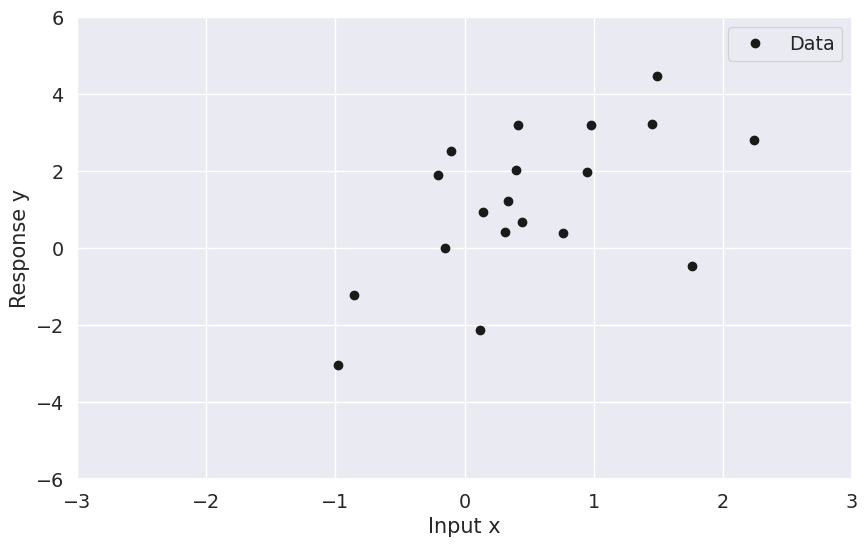

In [2]:
N = 20

# Define training input data (x values), shape (N, 1)
xtrain = jnp.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977,  0.95, -0.151, -0.103, 0.411, 0.144, 1.454, 0.761, 0.122,
              0.444, 0.334, 1.494, -0.205,  0.313, -0.854])[:, None]                                    # shape (N, 1)

# Define training output data (y values), shape (N, 1)
ytrain = jnp.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009, 2.513, 3.194, 0.935, 3.216, 0.386, -2.118,
               0.674, 1.222, 4.481, 1.893, 0.422,  -1.209])[:, None]                                   # shape (N, 1)

# Function to plot the toy dataset
def plot_toydata(ax):
    ax.plot(xtrain, ytrain, 'k.', label='Data', markersize=12)  # plot data points as black dots
    ax.set(xlabel='Input x', ylabel='Response y', xlim=(-3, 3), ylim=(-6, 6))  # set axis labels and limits
    ax.legend()  # show legend

# Create a new figure and axis for plotting
fig, ax = plt.subplots(1,1, figsize=(10, 6))
plot_toydata(ax)  # plot the toy data

The purpose of this part is to understand the basic building blocks of the linear model and reinforce the concepts of prior, likelihood, and posterior. First, we will define a convenient function for evaluating and plotting distributions using densities.

In [3]:
def plot_distribution(ax, x, y, density_fun, color=None, visibility=1, label=None, title=None, num_points=100):
    """
    Plots the contour of a density function over a grid of slope (a) and intercept (b) values.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The matplotlib axis to plot on.
    x : array-like
        Input data (features).
    y : array-like
        Output data (targets).
    density_fun : callable
        Function that takes (x, y, a, b) and returns log density values.
    color : str or None, optional
        Color for the contour lines.
    visibility : float, optional
        Alpha value for contour visibility (default is 1).
    label : str or None, optional
        Label for the plot legend.
    title : str or None, optional
        Title for the plot.
    num_points : int, optional
        Number of grid points for each parameter (default is 100).

    Example
    -------
    >>> fig, ax = plt.subplots()
    >>> plot_distribution(ax, xtrain, ytrain, density_fun=log_prior, color='b', title='Prior')
    """

    # Create grid for parameters (a: slope, b: intercept)
    a_array = jnp.linspace(-4, 4, num_points)
    b_array = jnp.linspace(-4, 4, num_points)
    A_array, B_array = jnp.meshgrid(a_array, b_array)

    # Form array with all combinations of (a, b) in our grid
    AB = jnp.column_stack((A_array.ravel(), B_array.ravel()))

    # Evaluate density for every point in the grid and reshape back
    Z = density_fun(x, y, A_array.ravel(), B_array.ravel())
    Z = Z.reshape((len(a_array), len(b_array)))

    # Plot contour of the density
    ax.contour(a_array, b_array, jnp.exp(Z), colors=color, alpha=visibility)
    # Add a dummy plot for legend
    ax.plot([-1000], [-1000], color=color, label=label)
    # Set axis labels, limits, and title
    ax.set(xlabel='slope', ylabel='intercept', xlim=(-4, 4), ylim=(-4, 4), title=title)
    
    
    

Then we will implement the prior, likelihood and posterior densities:

[[0.4804374]
 [1.6728646]]
[[0.544074]
 [1.242634]]
[[0.54407406]
 [1.242634  ]]


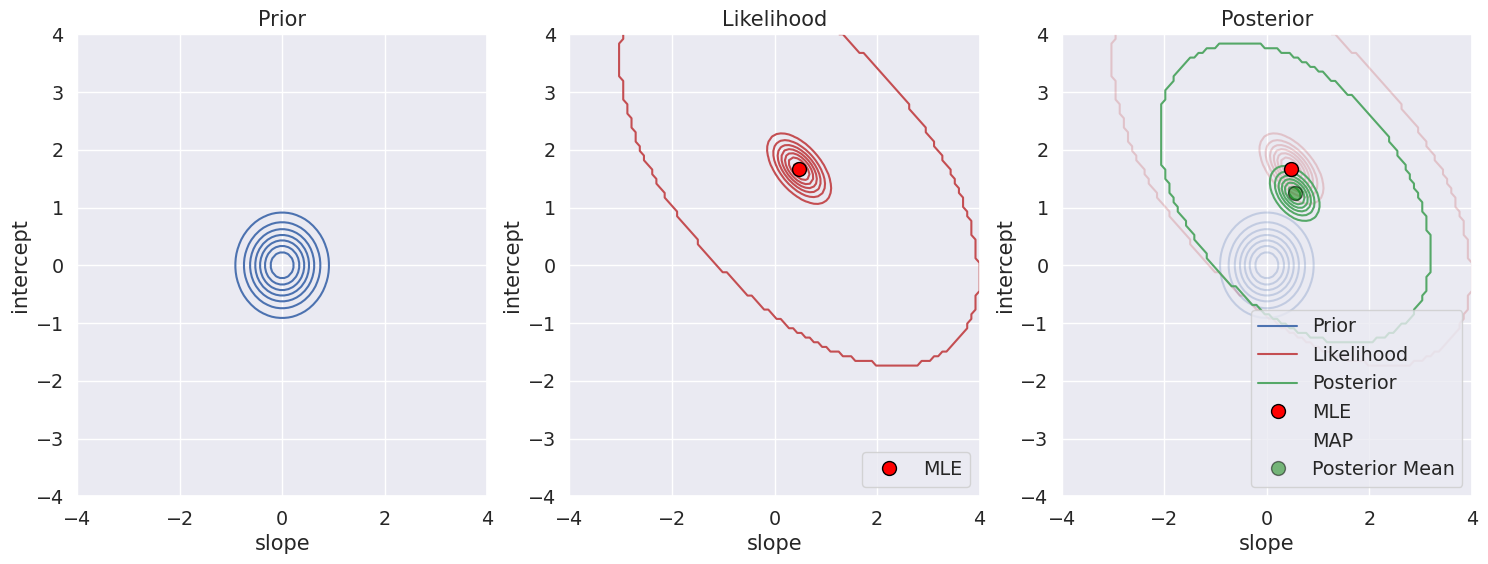

In [4]:

# --- Hyperparameters ---
alpha = 5     # Prior precision for parameters a and b
beta = 3 / 4  # Likelihood precision (inverse of observation noise variance)

# --- Helper functions ---

log_npdf = lambda x, m, v: -0.5 * jnp.log(2 * jnp.pi * v) - 0.5 * (x - m) ** 2 / v
predict = lambda x, a, b: a + b * x

def log_prior(x, y, a, b):
    """
    Compute the log prior probability of parameters (a, b).

    Parameters:
    - x: (n,) array of inputs (unused here)
    - y: (n,) array of targets (unused here)
    - a: scalar intercept
    - b: scalar slope

    Returns:
    - Scalar log prior value

    Example:
    >>> log_prior(None, None, 0.5, 1.0)
    -2.137...
    """
    return multivariate_normal.logpdf(jnp.column_stack([a, b]), jnp.array([0, 0]), 1/alpha*jnp.identity(2))

def log_likelihood(x, y, a, b):
    """
    Compute the total log likelihood of observed targets y given inputs x and parameters (a, b).

    Parameters:
    - x: (n,) array of input features
    - y: (n,) array of observed targets
    - a: scalar intercept
    - b: scalar slope

    Returns:
    - Scalar log likelihood

    Example:
    >>> x = jnp.array([1., 2., 3.])
    >>> y = jnp.array([2., 4., 6.])
    >>> log_likelihood(x, y, 0.0, 2.0)
    2.7...
    """
    y_pred = predict(x, a, b)
    return jnp.sum(log_npdf(y, y_pred, 1 / beta), axis=0)

def log_posterior(x, y, a, b):
    """
    Compute the log posterior (unnormalized) of parameters (a, b) given data (x, y).

    Parameters:
    - x: (n,) input features
    - y: (n,) target outputs
    - a: scalar intercept
    - b: scalar slope

    Returns:
    - Scalar log posterior

    Example:
    >>> x = jnp.array([1., 2., 3.])
    >>> y = jnp.array([2., 4., 6.])
    >>> log_posterior(x, y, 0.5, 2.0)
    0.7...
    """
    return log_prior(x, y, a, b) + log_likelihood(x, y, a, b)

def design_matrix(x):
    """
    Construct a design matrix Φ with a bias (intercept) term.

    Parameters:
    - x: (n,) input array

    Returns:
    - Φ: (n, 2) design matrix with ones in first column and x values in second

    Example:
    >>> x = jnp.array([1., 2., 3.])
    >>> design_matrix(x)
    DeviceArray([[1., 1.],
                 [1., 2.],
                 [1., 3.]], dtype=float32)
    """
    return jnp.column_stack((jnp.ones(len(x)), x))

def compute_mle(xtrain, ytrain):
    """
    Computes the Maximum Likelihood Estimate (MLE) weights for linear regression using a design matrix.

    Parameters:
    - xtrain: (n,) array of input features
    - ytrain: (n,) array of target values

    Returns:
    - w_mle: (2,) array of MLE weights [intercept, slope]

    Example:
    >>> xtrain = jnp.array([1.0, 2.0, 3.0])
    >>> ytrain = jnp.array([2.0, 4.0, 6.0])
    >>> compute_mle(xtrain, ytrain)
    DeviceArray([0., 2.], dtype=float32)
    """
    Phi = design_matrix(xtrain)
    w_mle = jnp.linalg.inv(Phi.T @ Phi) @ (Phi.T @ ytrain)
    return w_mle


def compute_map(xtrain, ytrain, alpha, beta):
    """
    Computes the Maximum A Posteriori (MAP) estimate for Bayesian linear regression
    with a Gaussian prior and Gaussian likelihood.

    Assumes the design matrix includes a bias term (intercept).

    Parameters:
    - xtrain: (n,) array of input features
    - ytrain: (n,) array of target values
    - alpha: prior precision (1 / variance of weights)
    - beta: noise precision (1 / observation noise variance)

    Returns:
    - w_map: (d,) array of MAP weights, where d = number of basis functions (e.g. 2 for [1, x])

    Example:diag_S = jnp.diag(model.S)
lower = model.m.ravel() - 1.96*jnp.sqrt(diag_S)
upper = model.m.ravel() + 1.96*jnp.sqrt(diag_S)
    >>> xtrain = jnp.array([1.0, 2.0, 3.0])
    >>> ytrain = jnp.array([2.0, 4.0, 6.0])
    >>> compute_map(xtrain, ytrain, alpha=1.0, beta=5.0)
    DeviceArray([0.6475408, 1.741573], dtype=float32)
    """
    Phi = design_matrix(xtrain)  # Shape (n, d)
    d = Phi.shape[1] 
    lambda_matrix = (alpha / beta) * jnp.eye(d) # shape (d, d)
    w_map = jnp.linalg.inv(Phi.T @ Phi + lambda_matrix) @ (Phi.T @ ytrain) # shape (d,)
    return w_map

def posterior_mean(xtrain, ytrain, beta, alpha):
    """
    Computes the posterior mean of the weights in Bayesian linear regression
    with a Gaussian prior and Gaussian likelihood.

    Parameters:
    - xtrain: (n,) array of input features
    - ytrain: (n,) array of target values
    - beta: noise precision (1 / observation noise variance)
    - alpha: prior precision (1 / variance of weights)

    Returns:
    - m: (d,) array — posterior mean vector of weights

    Example:
    >>> xtrain = jnp.array([1.0, 2.0, 3.0])
    >>> ytrain = jnp.array([2.0, 4.0, 6.0])
    >>> posterior_mean(xtrain, ytrain, beta=5.0, alpha=1.0)
    DeviceArray([0.6475408, 1.741573], dtype=float32)
    """
    Phi = design_matrix(xtrain)      # Shape (n, d)
    d = Phi.shape[1]
    S = jnp.linalg.inv(alpha * jnp.eye(d) + beta * Phi.T @ Phi) # shape (d, d)
    m = beta * S @ Phi.T @ ytrain # shape (d,)
    return m
    

# plot
fig, axes = plt.subplots(1, 3, figsize=(18,6))
plot_distribution(axes[0], xtrain, ytrain, density_fun=log_prior, color='b', title='Prior')
plot_distribution(axes[1], xtrain, ytrain, density_fun=log_likelihood, color='r', title='Likelihood')
plot_distribution(axes[2], xtrain, ytrain, density_fun=log_prior, color='b', visibility=0.25, label='Prior')
plot_distribution(axes[2], xtrain, ytrain, density_fun=log_likelihood, color='r', visibility=0.25, label='Likelihood')
plot_distribution(axes[2], xtrain, ytrain, density_fun=log_posterior, color='g', label='Posterior', title='Posterior')


##################################################################
# Insert your solution here
##################################################################

# MLE estimate 

MLE = compute_mle(xtrain, ytrain)
print(MLE)


MAP = compute_map(xtrain, ytrain, alpha, beta)
print(MAP)

P_MEAN = posterior_mean(xtrain, ytrain, beta, alpha)
print(P_MEAN)


axes[1].plot([MLE[0]], [MLE[1]], 
             marker='o', markerfacecolor='red', markeredgecolor='black', 
             linestyle='none', label='MLE', ms=10)


axes[2].plot([MLE[0]], [MLE[1]], 
             marker='o', markerfacecolor='red', markeredgecolor='black', 
             linestyle='none', label='MLE', ms=10)


axes[2].plot([MAP[0]], [MAP[1]], 
             marker='o', markerfacecolor='blue', markeredgecolor='black', 
             linestyle='none', label='MAP', ms=10, alpha=.0)

axes[2].plot([P_MEAN[0]], [P_MEAN[1]], 
             marker='o', markerfacecolor='green', markeredgecolor='black', 
             linestyle='none', label='Posterior Mean', ms=10, alpha=0.5)


##################################################################
# end of solution
##################################################################

axes[1].legend(loc='lower right');
axes[2].legend(loc='lower right');


**Task 1.1**: Compute the maximum likelihood solution (MLE), the MAP solution and the posterior mean for the slope and intercept. Plot all three points in the right-most panel above.

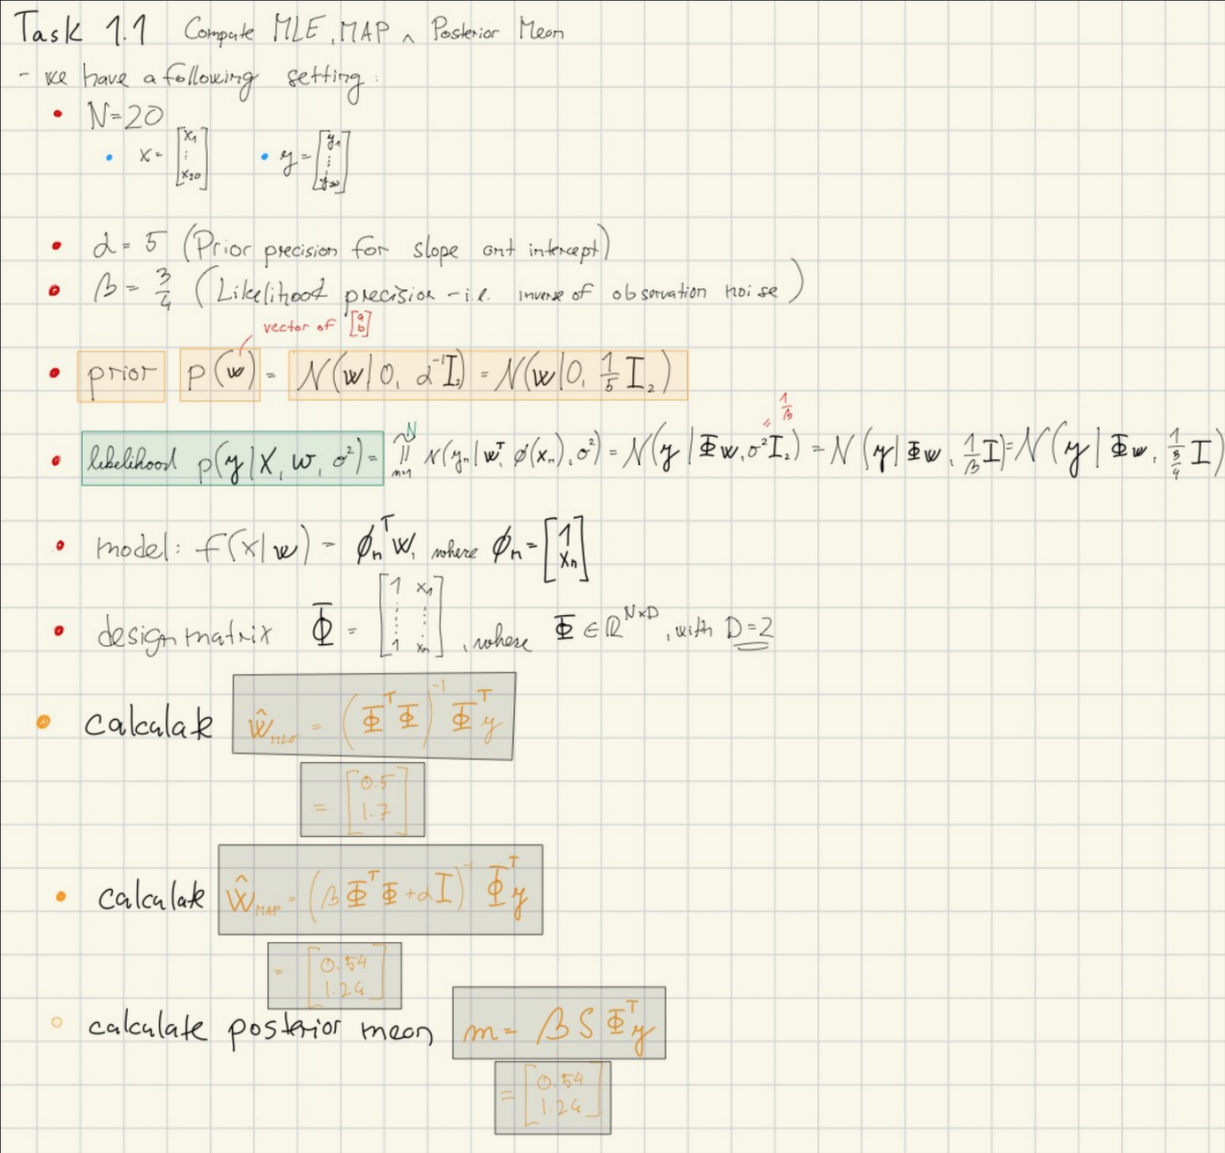

**Task 1.2**: Explain the role of $\alpha$ and $\beta$ based on the plots above. What happens if you increase or decrease $\alpha$ or $\beta$?  [**Discussion question**]


| #  | Scenario                      | α     | β    | α / β  | Prior strength | Likelihood (noise)          | Posterior width | MAP = Posterior mean ( intercept , slope ) | How the MAP shifts                                    |
| -- | ----------------------------- | ----- | ---- | ------ | -------------- | ----------------------------|---------------------------- | ------------------------------------------ | ----------------------------------------------------- |
|  1 | Flat prior, baseline β        | 0.1   | 0.75 | 0.133  | *flat‑ish*     | baseline (moderate width)   |  broad| (0.484 , 1.660)                            | **MAP ≈ MLE** → data dominate                         |
|  2 | Strong prior, baseline β      | 20    | 0.75 | 26.667 | **strong**     | baseline                    | medium | (0.432 , 0.747)                            | **Strong shrink toward prior**                        |
|  3 | High‑noise likelihood (β ↓)   | 5     | 0.1  | 50.000 | moderate       | very high noise (very broad)| very broad| (0.325 , 0.519)                            | **Strong shrink toward prior** (data very unreliable) |
|  4 | Low‑noise likelihood (β ↑)    | 5     | 10   | 0.500  | moderate       | low noise (sharp)           |very narrow | (0.495 , 1.626)                            | Noticeable, but mild, pull to prior                   |
|  5 | Almost flat prior + low noise | 0.001 | 5    | 0.0002 | *almost flat*  | low noise (sharp)           |narrow | (0.480 , 1.673)                            | **MAP ≈ MLE** (prior negligible)                      |


_____

##### 1)  
 - 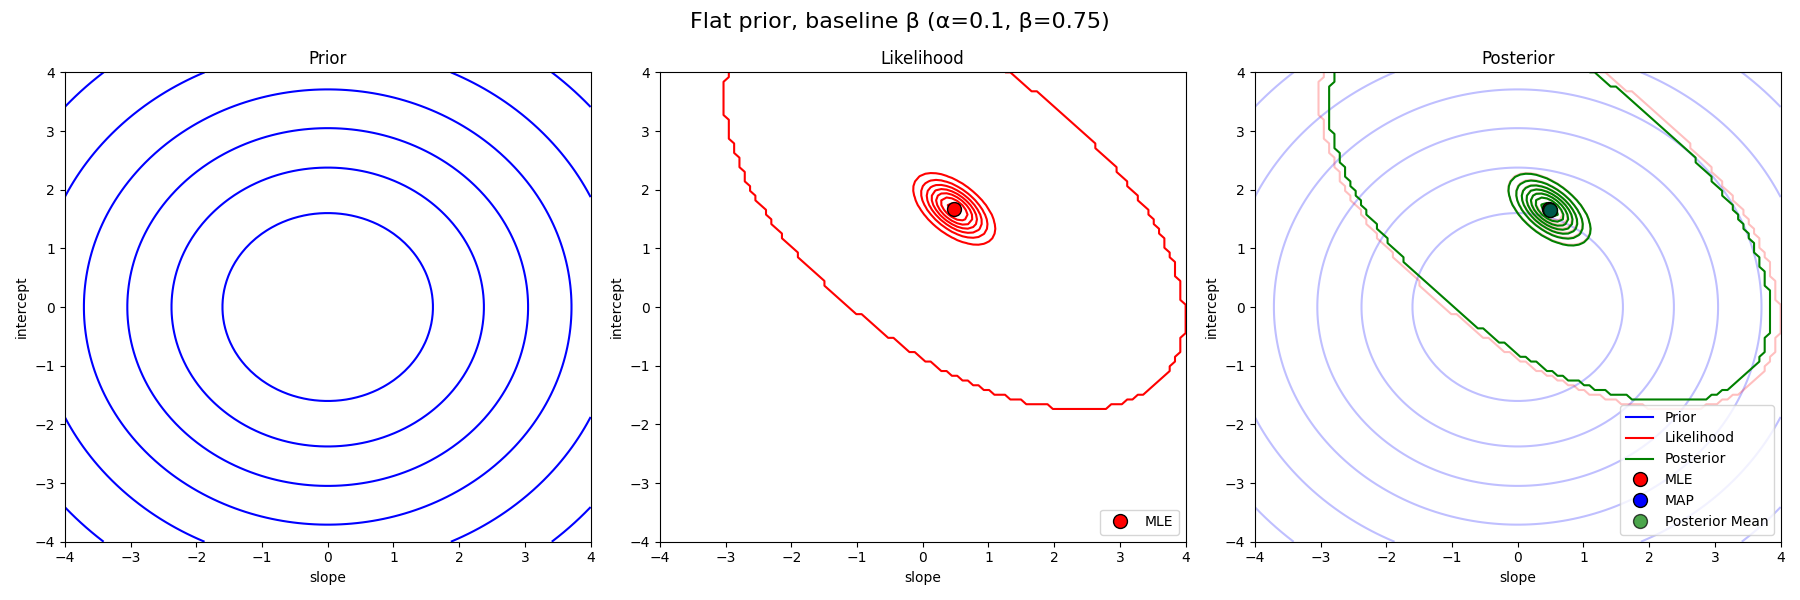

##### 2)
- 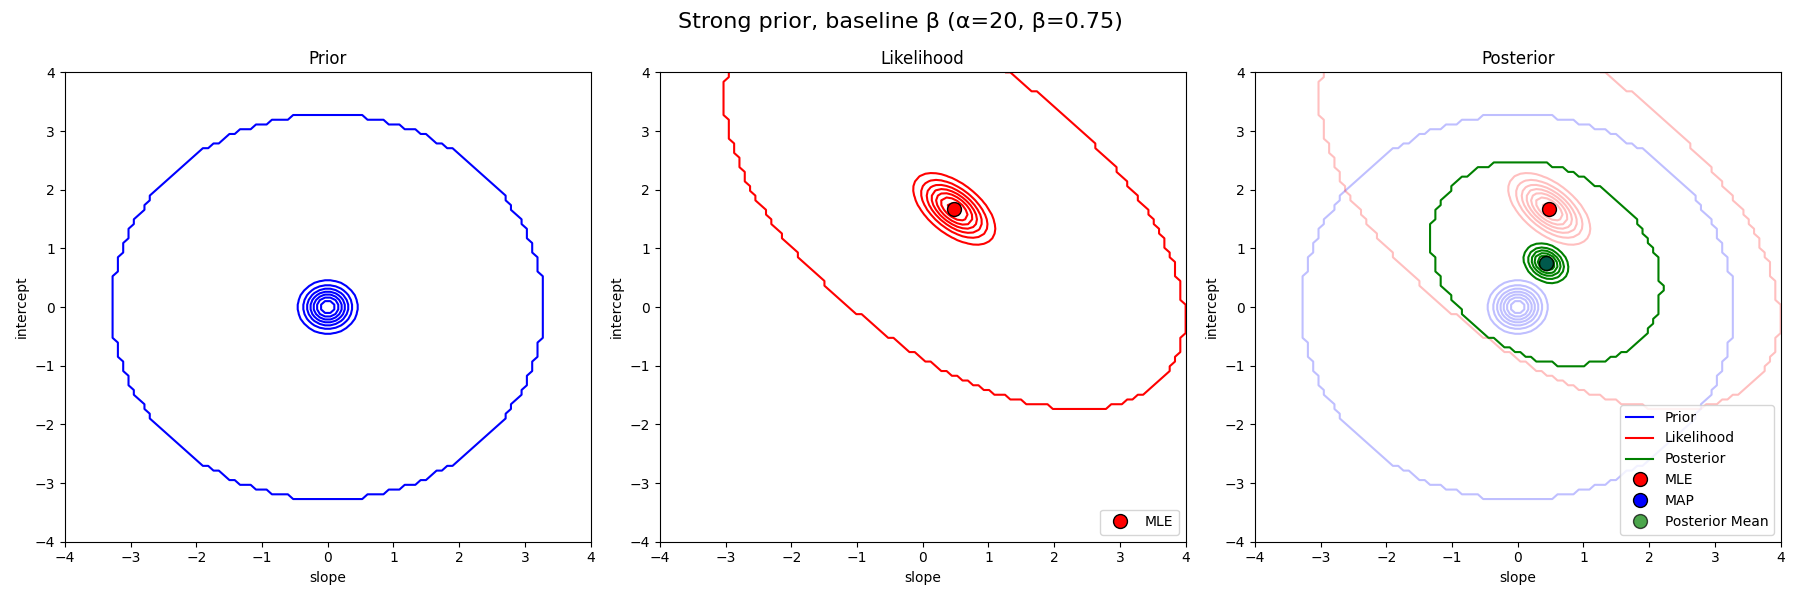

##### 3)
-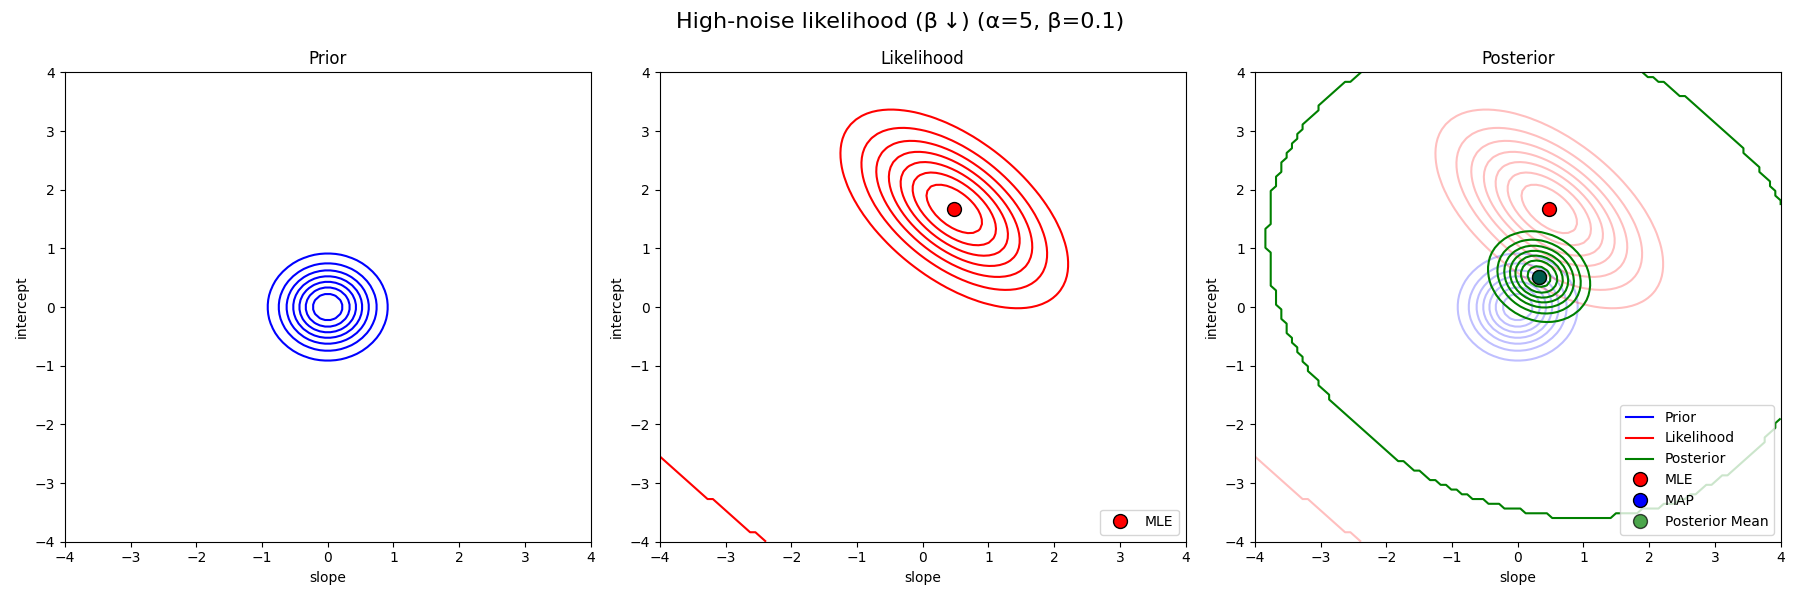

##### 4)
- 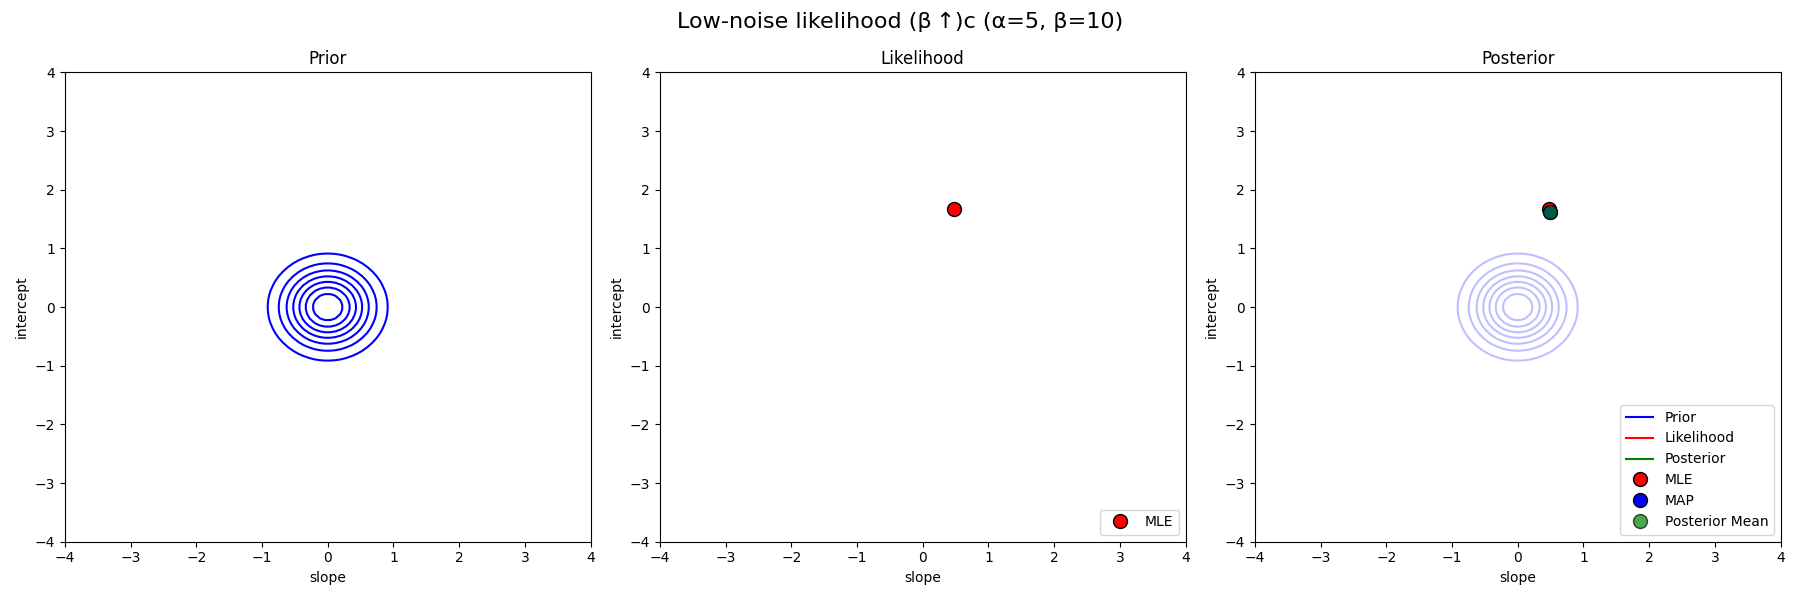

##### 5)
-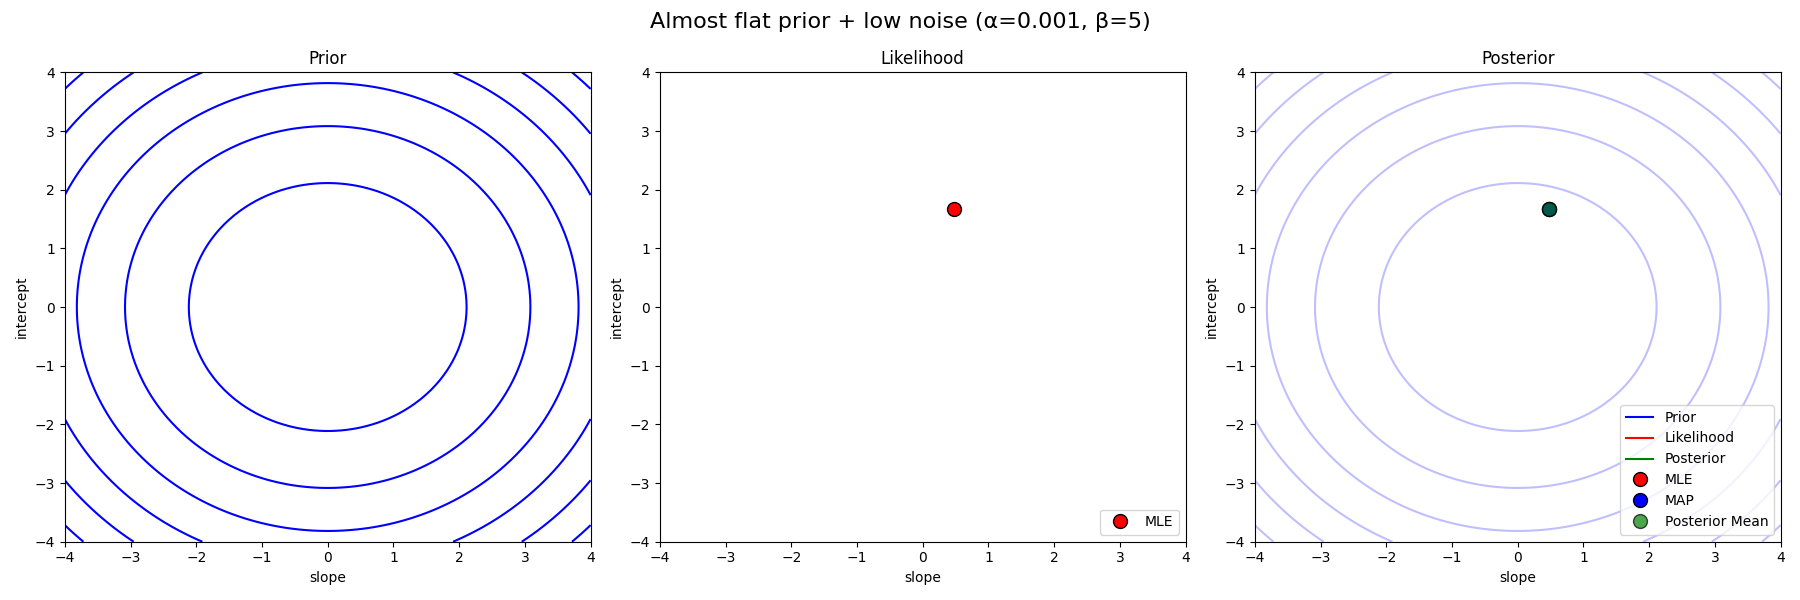

**Task 1.3**: What happens to the posterior mean and covariance if you let $\beta$ approach zero (this is equivalent to the noise variance going to infinity)? Explain what you see using eq. (1) and (2) above.






**Task 1.4** Show that when we make the prior distribution infinitely wide, i.e. $\alpha \rightarrow 0$, then the posterior mean converges to the maximum likelihood solution.


*Hints*: 
- Recall: $\mathbf{S}_0 = \alpha^{-1}\mathbf{I}$
- Substitute the expression for the posterior covariance in eq. (1) into the expression for the posterior mean in eq. (2) and take the limit $\alpha \rightarrow 0$.




## Part 2:  Implementing the posterior distribution

In the cell below, you are given an incomplete implementation of Bayesian linear regression. Your task is to complete the implementation. See details below.

#### Mathematical background
----------------------
Given an $N\times D$ design matrix $\Phi$ (one row per training example, one
column per basis function) and a target vector $\mathbf y\in\mathbb R^{N}$, we
model the conditional distribution

$$
    y_n = \mathbf w^\top \boldsymbol\phi(x_n) + \varepsilon_n,\quad
    \varepsilon_n \sim \mathcal N(0, \beta^{-1}),
$$
where $\mathbf w\in\mathbb R^{D}$ are the **weights** and $\beta$ (precision)
controls the homoscedastic Gaussian observation noise. A zero‑mean isotropic
Gaussian prior is placed on the weights

$$
    p(\mathbf w\mid\alpha) = \mathcal N(\mathbf 0,\;\alpha^{-1}\mathbf I_D),
$$
with precision hyper‑parameter $\alpha$.

### Posterior distribution
Bayes' rule yields a Gaussian posterior

$$
    p(\mathbf w\mid\mathbf y,\alpha,\beta) =
        \mathcal N(\mathbf w\mid \mathbf m,\;\mathbf S),
$$
with

\begin{align}
    \mathbf S^{-1} &= \alpha\mathbf I_D + \beta \Phi^\top \Phi,\\
    \mathbf m      &= \beta\,\mathbf S\,\Phi^\top\mathbf y. \tag{1}
\end{align}

### Marginal likelihood (evidence)
The log marginal likelihood (evidence) is

$$
\begin{aligned}
\log p(\mathbf y\mid\alpha,\beta)
  &= \tfrac{D}{2}\log\alpha + \tfrac{N}{2}\log\beta
   - \tfrac{1}{2}\log |\mathbf S^{-1}|
   - \tfrac{\beta}{2}\|\mathbf y-\Phi\mathbf m\|^2
   - \tfrac{\alpha}{2}\|\mathbf m\|^2
   - \tfrac{N}{2}\log(2\pi).\tag{2}
\end{aligned}
$$

Maximising Eq. (2) with respect to $(\alpha,\beta)$ gives **type‑II maximum
likelihood (Empirical Bayes)** estimates of the hyper‑parameters.

### Predictive distribution
For a new design matrix $\Phi_*$,

\begin{aligned}
    f_*             &= \Phi_*\mathbf w,\\
    y_* \mid f_*    &\sim \mathcal N(f_*,\;\beta^{-1}).
\end{aligned}

Integrating over the posterior yields

\begin{aligned}
    \mu_f &= \mathbb E[f_*] = \Phi_*\mathbf m,\\
    \operatorname{Var}[f_*] &= \operatorname{diag}(\Phi_*\mathbf S\Phi_*^\top),\\
    \mu_y &= \mu_f,\\
    \operatorname{Var}[y_*] &= \operatorname{Var}[f_*] + \beta^{-1}.\tag{3}
\end{aligned}

------------------------------------------------------------------------
Usage example
-------------
```python
>>> import jax.numpy as jnp
>>> from bayesian_linear_regression_detailed import BayesianLinearRegression
>>> import jax

>>> key = jax.random.PRNGKey(0)

# Toy data: two features, two datapoints
>>> Phi = 0.5 * jnp.ones((2, 2))
>>> y   = 2.0 * jnp.ones((2, 1))

>>> model = BayesianLinearRegression(Phi, y, alpha=0.5, beta=0.5)

# Posterior mean ≈ [[1.], [1.]]
>>> model.m
Array([[1.],
       [1.]], dtype=float32)

# Posterior covariance
>>> model.S
Array([[ 1.5, -0.5],
       [-0.5,  1.5]], dtype=float32)
```
______

In [ ]:
class BayesianLinearRegression(object):
    """
    Bayesian Linear Regression Implementation
    
    This class implements Bayesian linear regression with Gaussian priors and likelihood.
    The model assumes:
    - Prior: w ~ N(0, α^(-1)I) where α is the precision (inverse variance) of weights
    - Likelihood: y = Φw + ε, where ε ~ N(0, β^(-1)) and β is noise precision
    - Posterior: w|y ~ N(m, S) where m and S are computed analytically
    
    Mathematical Framework:
    =====================
    Given training data (Φ, y) where Φ is [N×D] design matrix and y is [N×1] targets:
    
    Prior Distribution:
    p(w) = N(w | 0, α^(-1)I)
    
    Likelihood:
    p(y | w, Φ, β) = N(y | Φw, β^(-1)I)
    
    Posterior Distribution:
    p(w | y, Φ, α, β) = N(w | m, S)
    
    Where:
    S^(-1) = αI + βΦ^T Φ                    (posterior precision matrix)
    S = (αI + βΦ^T Φ)^(-1)                  (posterior covariance matrix)
    m = βS Φ^T y                            (posterior mean)
    
    Predictive Distribution:
    For new input Φ*, the predictive distribution of function values f* = Φ*w is:
    p(f* | Φ*, y, Φ, α, β) = N(f* | μ_f, Σ_f)
    
    Where:
    μ_f = Φ* m                              (predictive mean)
    Σ_f = Φ* S Φ*^T                        (predictive covariance)
    
    For output predictions y* = f* + ε:
    p(y* | Φ*, y, Φ, α, β) = N(y* | μ_y, Σ_y)
    
    Where:
    μ_y = μ_f                               (same mean)
    Σ_y = Σ_f + β^(-1)I                    (additional noise variance)
    
    Parameters:
    -----------
    Phi : jnp.ndarray, shape (N, D)
        Design matrix where N is number of data points and D is number of features
    y : jnp.ndarray, shape (N, 1)
        Target values
    alpha : float, default=1.0
        Precision (inverse variance) of the weight prior: p(w) ~ N(0, α^(-1)I)
        Higher α means stronger regularization (weights closer to zero)
    beta : float, default=1.0
        Precision (inverse variance) of the noise: p(ε) ~ N(0, β^(-1))
        Higher β means lower noise assumption
    
    Attributes:
    -----------
    Phi : jnp.ndarray
        Stored design matrix
    y : jnp.ndarray
        Stored target values
    N : int
        Number of data points
    D : int
        Number of features/basis functions
    alpha : float
        Weight precision hyperparameter
    beta : float
        Noise precision hyperparameter
    m : jnp.ndarray, shape (D, 1)
        Posterior mean of weights
    S : jnp.ndarray, shape (D, D)
        Posterior covariance matrix of weights
    log_marginal_likelihood : float
        Log marginal likelihood p(y|α,β)
    
    Example:
    --------
    >>> import jax.numpy as jnp
    >>> # Create synthetic data
    >>> N, D = 100, 3
    >>> Phi = jnp.random.normal(0, 1, (N, D))  # Design matrix
    >>> true_weights = jnp.array([1.5, -0.8, 2.1])
    >>> y = (Phi @ true_weights + 0.1 * jnp.random.normal(0, 1, N)).reshape(-1, 1)
    >>> 
    >>> # Fit Bayesian linear regression
    >>> model = BayesianLinearRegression(Phi, y, alpha=1.0, beta=25.0)
    >>> 
    >>> # Make predictions on new data
    >>> Phi_test = jnp.random.normal(0, 1, (10, D))
    >>> mu_y, var_y = model.predict_y(Phi_test)
    >>> print(f"Predictive mean: {mu_y}")
    >>> print(f"Predictive variance: {var_y}")
    """
    
    def __init__(self, Phi, y, alpha=1., beta=1.):
        """
        Initialize Bayesian Linear Regression model.
        
        Computes the posterior distribution p(w|y,Φ,α,β) = N(w|m,S) analytically
        and stores all relevant quantities for prediction and inference.
        
        Parameters:
        -----------
        Phi : jnp.ndarray, shape (N, D)
            Design matrix containing basis function evaluations
        y : jnp.ndarray, shape (N, 1)
            Target values (must be column vector)
        alpha : float, default=1.0
            Precision of weight prior (higher = more regularization)
        beta : float, default=1.0
            Precision of noise (higher = assume less noise)
        
        Example:
        --------
        >>> Phi = jnp.array([[1, 2], [1, 3], [1, 4]])  # Linear basis [1, x]
        >>> y = jnp.array([[3], [4], [5]])              # Linear relationship
        >>> model = BayesianLinearRegression(Phi, y, alpha=1.0, beta=1.0)
        """
        
        # store data and hyperparameters
        self.Phi, self.y = Phi, y
        self.N, self.D = Phi.shape
        self.alpha, self.beta = alpha, beta
        
        # compute posterior distribution
        self.m, self.S = self.compute_posterior(alpha, beta)
        self.log_marginal_likelihood = self.compute_marginal_likelihood(alpha, beta)

        # perform sanity check of shapes/dimensions
        self.check_dimensions()
        
    def check_dimensions(self):
        """
        Verify that all arrays have correct dimensions.
        
        This is a sanity check to ensure mathematical operations are valid
        and catch dimension mismatches early in development.
        
        Raises:
        -------
        AssertionError
            If any array has incorrect dimensions
        
        Expected Dimensions:
        -------------------
        y : (N, 1) - targets must be column vector
        m : (D, 1) - posterior mean must be column vector  
        S : (D, D) - posterior covariance must be square matrix
        
        Example:
        --------
        >>> model = BayesianLinearRegression(Phi, y)
        >>> model.check_dimensions()  # Will raise error if shapes are wrong
        """
        D = self.D
        N = self.N
        
        # Check target vector dimensions
        assert self.y.shape == (N, 1), (
            f"Wrong shape for data vector y.\n"
            f"For N = {N}, the shape of y must be ({N}, 1), "
            f"but the actual shape is {self.y.shape}"
        )
        
        # Check posterior mean dimensions  
        assert self.m.shape == (D, 1), (
            f"Wrong shape for posterior mean.\n"
            f"For D = {D}, the shape of the posterior mean must be ({D}, 1), "
            f"but the actual shape is {self.m.shape}"
        )
        
        # Check posterior covariance dimensions
        assert self.S.shape == (D, D), (
            f"Wrong shape for posterior covariance.\n"
            f"For D = {D}, the shape of the posterior covariance must be ({D}, {D}), "
            f"but the actual shape is {self.S.shape}"
        )
    def compute_posterior(self, alpha, beta):
        """
        Compute the posterior distribution p(w|y,Φ,α,β) = N(w|m,S) analytically.
        
        This implements the core Bayesian inference for linear regression.
        Given a Gaussian prior p(w) = N(0, α^(-1)I) and Gaussian likelihood
        p(y|w,Φ,β) = N(Φw, β^(-1)I), the posterior is also Gaussian.
        
        Mathematical Derivation:
        ========================
        Starting from Bayes' theorem:
        p(w|y,Φ,α,β) ∝ p(y|w,Φ,β) p(w|α)
        
        Both likelihood and prior are Gaussian, so posterior is Gaussian:
        p(w|y,Φ,α,β) = N(w|m,S)
        
        The posterior precision (inverse covariance) combines prior and data precision:
        S^(-1) = α I + β Φ^T Φ
        
        Where:
        - α I represents prior precision (regularization)
        - β Φ^T Φ represents data precision (how much data informs each parameter)
        
        The posterior covariance is:
        S = (α I + β Φ^T Φ)^(-1)
        
        The posterior mean balances prior (zero) and data evidence:
        m = β S Φ^T y
        
        Intuition:
        - If α is large: strong prior → m closer to 0, S smaller (more certain)
        - If β is large: trust data more → m closer to least squares solution
        - If data is abundant: Φ^T Φ large → posterior dominated by data
        
        Parameters:
        -----------
        alpha : float
            Prior precision parameter
        beta : float  
            Noise precision parameter
            
        Returns:
        --------
        m : jnp.ndarray, shape (D, 1)
            Posterior mean vector
        S : jnp.ndarray, shape (D, D)
            Posterior covariance matrix
            
        Example:
        --------
        >>> model = BayesianLinearRegression(Phi, y)
        >>> m, S = model.compute_posterior(alpha=2.0, beta=1.0)
        >>> print(f"Posterior mean: {m.ravel()}")
        >>> print(f"Posterior uncertainty (diagonal of S): {jnp.diag(S)}")
        """
        #############################################
        # Bayesian Linear Regression Posterior Computation
        #############################################
        
        # Prior precision matrix: p(w) = N(0, α^(-1)I)
        # This represents our belief that weights should be close to zero
        # Higher α = stronger regularization = weights pulled toward zero
        S0_inv = alpha * jnp.eye(self.D)  # Prior precision: α I
        
        # Posterior precision matrix (inverse covariance):
        # S^(-1) = α I + β Φ^T Φ
        # This combines:
        # - Prior precision α I (regularization term)
        # - Data precision β Φ^T Φ (how much each parameter is constrained by data)
        A = S0_inv + beta * self.Phi.T @ self.Phi  # Posterior precision matrix
        
        # Posterior covariance matrix:
        # S = (α I + β Φ^T Φ)^(-1)
        # This tells us the uncertainty in our weight estimates
        # Smaller values = more certain estimates
        S = jnp.linalg.inv(A)  # Posterior covariance matrix
        
        # Posterior mean:
        # m = β S Φ^T y
        # This is the weighted combination of prior mean (0) and data evidence
        # When β is large (low noise), this approaches the least squares solution
        m = beta * S @ self.Phi.T @ self.y  # Posterior mean vector
        
        #############################################
        # End of solution
        #############################################
        return m, S      
    def generate_prior_samples(self, key, num_samples):
        """ generate samples from the prior  """
        return random.multivariate_normal(key, jnp.zeros(len(self.m)), (1/self.alpha)*jnp.identity(len(self.m)), shape=(num_samples, ))
    
    def generate_posterior_samples(self, key, num_samples):
        """ generate samples from the posterior  """
        return random.multivariate_normal(key, self.m.ravel(), self.S, shape=(num_samples, ))
    
    def predict_f(self, Phi):
        """ computes posterior mean (mu_f) and variance (var_f) of f(phi(x)) for each row in Phi-matrix. If Phi is a [N, D]-matrix, then the shapes of both mu_f and var_f must be (N,). The function returns (mu_f, var_f)
        """
        mu_f = (Phi@self.m).ravel()   
        var_f = jnp.diag(Phi@self.S@Phi.T)   
        
        # check dimensions before returning values
        assert mu_f.shape == (Phi.shape[0],), "Shape of mu_f seems wrong. Check your implementation"
        assert var_f.shape == (Phi.shape[0],), "Shape of var_f seems wrong. Check your implementation"
        return mu_f, var_f
        
    def predict_y(self, Phi):
        """ returns posterior predictive mean (mu_y) and variance (var_y) of y = f(phi(x)) + e for each row in Phi-matrix. If Phi is a [N, D]-matrix, then the shapes of both mu_y and var_y must be (N,). The function returns (mu_y, var_y)
        """
        mu_f, var_f = self.predict_f(Phi)
        mu_y = mu_f                  
        var_y = var_f + 1/self.beta  

        # check dimensions before returning values
        assert mu_y.shape == (Phi.shape[0],), "Shape of mu_y seems wrong. Check your implementation"
        assert var_y.shape == (Phi.shape[0],), "Shape of var_y seems wrong. Check your implementation"
        return mu_y, var_y
        
    
    def compute_marginal_likelihood(self, alpha, beta):
        """ computes and returns log marginal likelihood p(y|alpha, beta) """
        inv_S0 = alpha*jnp.identity(self.D)
        A = inv_S0 + beta*(self.Phi.T@self.Phi)
        m = beta*jnp.linalg.solve(A, self.Phi.T)@self.y   # (eq. 3.53 in Bishop)
        S = jnp.linalg.inv(A)                             # (eq. 3.54 in Bishop)
        Em = beta/2*jnp.sum((self.y - self.Phi@m)**2) + alpha/2*jnp.sum(m**2)
        return self.D/2*jnp.log(alpha) + self.N/2*jnp.log(beta) - Em - 0.5*jnp.linalg.slogdet(A)[1] - self.N/2*jnp.log(2*jnp.pi)
         

    def optimize_hyperparameters(self):
        # optimizes hyperparameters using marginal likelihood
        theta0 = jnp.array((jnp.log(self.alpha), jnp.log(self.beta)))
        def negative_marginal_likelihood(theta):
            alpha, beta = jnp.exp(theta[0]), jnp.exp(theta[1])
            return -self.compute_marginal_likelihood(alpha, beta)

        result = minimize(value_and_grad(negative_marginal_likelihood), theta0, jac=True)

        # store new hyperparameters and recompute posterior
        theta_opt = result.x
        self.alpha, self.beta = jnp.exp(theta_opt[0]), jnp.exp(theta_opt[1])
        self.m, self.S = self.compute_posterior(self.alpha, self.beta)
        self.log_marginal_likelihood = self.compute_marginal_likelihood(self.alpha, self.beta)
    def get_w_mle(self):
        """
        Compute the Maximum Likelihood Estimate (MLE) of weights.
        
        This corresponds to the least squares solution:
        w_MLE = (ΦᵀΦ)^(-1) Φᵀy
        
        Returns:
        --------
        w_mle : jnp.ndarray, shape (D, 1)
            MLE estimate of weights
        """
        PhiT_Phi_inv = jnp.linalg.inv(self.Phi.T @ self.Phi)
        w_mle = PhiT_Phi_inv @ self.Phi.T @ self.y
        return w_mle

    def get_sigma2_mle(self):
        """
        Compute the MLE of the noise variance σ² using the residuals of the MLE fit:
        σ²_MLE = (1/N) * ||y - Φ w_MLE||²

        Returns:
        --------
        sigma2_mle : float
            Maximum likelihood estimate of the noise variance
        """
        w_mle = self.get_w_mle()
        residuals = self.y - self.Phi @ w_mle
        sigma2_mle = jnp.sum(residuals**2) / self.N
        return sigma2_mle

    def get_w_map(self):
        """
        Returns the MAP estimate of weights.

        Since the prior and likelihood are Gaussian, the posterior is Gaussian,
        and the MAP estimate is simply the posterior mean `m`.

        Returns:
        --------
        w_map : jnp.ndarray, shape (D, 1)
            MAP estimate of weights (posterior mean)
        """
        return self.m


# sanity check of implementation
model = BayesianLinearRegression(0.5*jnp.ones((2,2)), 2*jnp.ones((2, 1)), alpha=0.5, beta=0.5)       
assert jnp.allclose(model.m, jnp.array([1, 1])), "Something seems to be wrong with your implementation of the posterior mean. Please check your implementation." 
assert jnp.allclose(model.S, jnp.array([[1.5, -0.5], [-0.5, 1.5]])), "Something seems to be wrong with your implementation of the posterior covariance. Please check your implementation." 

# fit model to toy dataset
Phi_train = design_matrix(xtrain)
model = BayesianLinearRegression(Phi_train, ytrain)


**Task 2.1**: Complete the implementation of the function *compute_posterior* above using eq. (1) and (2).




**Task 2.2**: Report the posterior mean and a 95\% credibility interval for the intercept and slope for $\alpha=\beta=1$. Compare your estimate to the plot of the data above. Do the results look reasonable compared to the plots above?

*Hint: There are several ways to approach this. E.g. for a Gaussian random variable $\mathcal{N}(\mu, \sigma^2)$, the interval $\left[\mu - 1.96\sigma, \mu + 1.96\sigma\right]$ contains approximately 95\% of its probability mass.*


In [6]:
##############################################
# Your solution goes here
##############################################

# 1️⃣  Posterior mean (scalars)  -------------------------------------------
#     Equation:  m_N = β S_N Φᵀ y     (Eq. 1 in BLR theory)
#     Shape: model.m is (D,1) with D=2  → (2,1)
#     We extract its two entries and cast to Python floats.

intercept = float(model.m[0, 0])   # row 0 → weight w₀  (intercept)
slope     = float(model.m[1, 0])   # row 1 → weight w₁  (slope)

# 2️⃣  Posterior variance of each weight  -----------------------------------
#     We need the diagonal of S_N (a 2×2 covariance matrix).
#     Equation:  S_N⁻¹ = αI + β Φᵀ Φ
#     diag_S[0] = Var(w₀) ,  diag_S[1] = Var(w₁)
#     Shape: diag_S is (2,)

diag_s = jnp.diag(model.S)

# 3️⃣  95 % credible intervals  --------------------------------------------
#     For a Gaussian weight w ~ N(μ, σ²),
#     CI₉₅ = [ μ − 1.96 σ ,  μ + 1.96 σ ].
#     Here we vectorise by using model.m.ravel() → (2,) and diag_s → (2,).
#     The two resulting tuples each contain *both* bounds; we'll index later.

ci_intercept = (
    model.m.ravel() - 1.96 * jnp.sqrt(diag_s),   # lower bounds for both weights
    model.m.ravel() + 1.96 * jnp.sqrt(diag_s)    # upper bounds for both weights
)

ci_slope = (
    model.m.ravel() - 1.96 * jnp.sqrt(diag_s),   # identical calc; you will pick index 1
    model.m.ravel() + 1.96 * jnp.sqrt(diag_s)
)

# 4️⃣  Pretty-print results  -------------------------------------------------
#     We index [0] to pick the intercept bounds, [1] for slope bounds.

print(f"Intercept\n"
      f"  posterior mean : {intercept:3.2f}\n"
      f"  95 % interval  : [{ci_intercept[0][0]:3.2f}, {ci_intercept[1][0]:3.2f}]")

print(f"Slope\n"
      f"     posterior mean : {slope:3.2f}\n"
      f"     95 % interval  : [{ci_slope[0][1]:3.2f}, {ci_slope[1][1]:3.2f}]")

##############################################
# End of solution
##############################################


Intercept
  posterior mean : 0.51
  95 % interval  : [0.00, 1.01]
Slope
     posterior mean : 1.58
     95 % interval  : [1.09, 2.08]


### Part 3:  The posterior predictive distribution

Next, we will use our toy dataset from above to study the relationship between the posterior distribution $p(\mathbf{w}|\mathbf{y})$ and the posterior predictive distribution $p(y^*|\mathbf{x}^*, \mathbf{y})$.
After we obtained the posterior distribution $p(\mathbf{w}|\mathbf{y}) = \mathcal{N}(\mathbf{w}| \mathbf{m}, \mathbf{S})$, we can also compute the distributions of $f_* = f(\mathbf{x}_*) = \phi(x_*)^T \mathbf{w}$ and $y_* = f(\mathbf{x}_*) + e$ for any new data point $\mathbf{x}_*$:

$$\begin{align*}
p(f_*|\mathbf{y}, \mathbf{x}_*) &=  \mathcal{N}(f_*|\phi_*^T\mathbf{m}, \phi_*^T\mathbf{S} \phi_*)\\
p(y_*|\mathbf{y}, \mathbf{x}_*) &=  \mathcal{N}(y_*|\phi_*^T\mathbf{m}, \phi_*^T\mathbf{S} \phi_* + \beta^{-1}).
\end{align*}$$

We often refer to the former as the **posterior distribution of $f_*$** and to latter as the **posterior predictive distribution for $y_*$**. Before studying the relationship, let's implement the two distributions.



**Task 3.1**: Go back up to the implementation of the class *BayesianLinearRegression* and complete the implementation of the functions *predict_f* and *predict_y*. These functions compute and return the mean and variance of $p(f_*|\mathbf{x}_*, \mathbf{y})$ and $p(y_*|\mathbf{x}_*, \mathbf{y})$, respectively, for a design matrix of new input points.

*Hints: The cell below will do a simple sanity check of your implementation. Passing the sanity check does not guarantee that your implementation is correct, though*


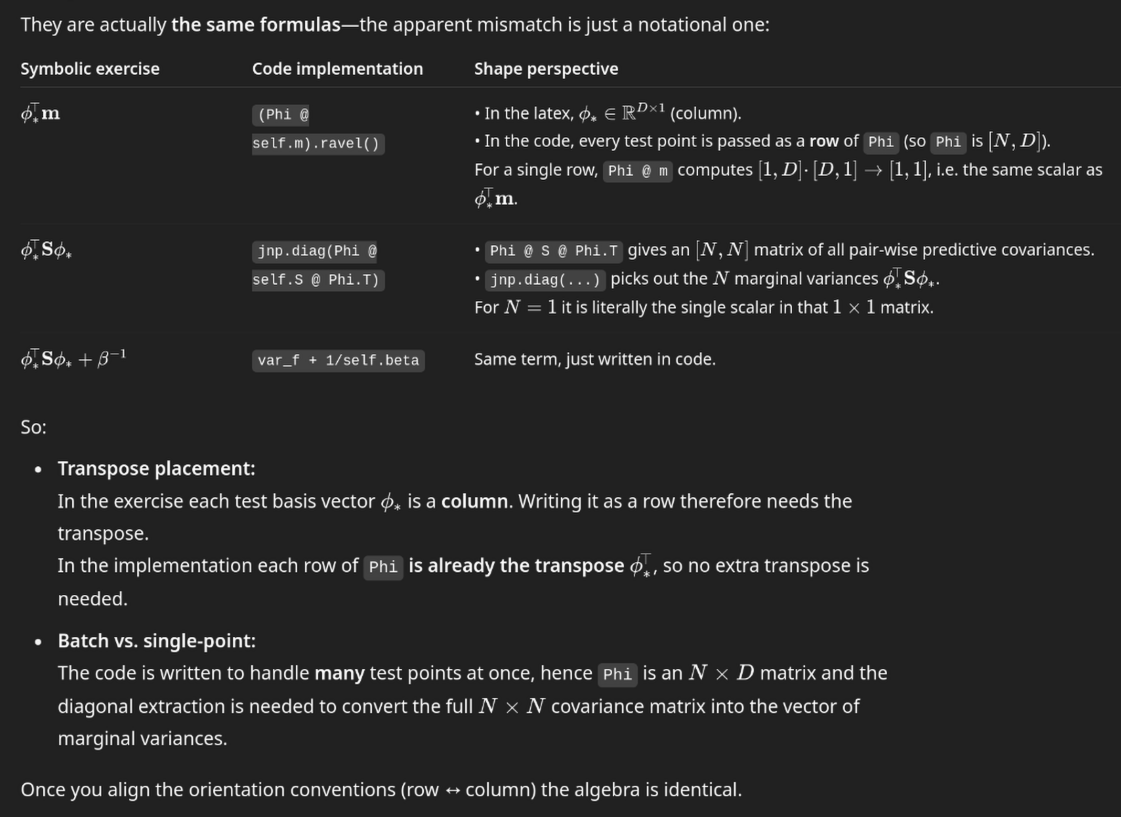


### Shapes and Dimensions 

| Symbol / Quantity                                                                 | Code variable(s)             | Shape *(rows × cols)* | Notes                                                  |
| --------------------------------------------------------------------------------- | ---------------------------- | --------------------- | ------------------------------------------------------ |
| **Training data**                                                                 |                              |                       |                                                        |
| $N$                                                                             | `self.N`                     | scalar                | Number of training cases                               |
| $D$                                                                             | `self.D`                     | scalar                | Number of basis functions / weights                    |
| $\Phi$                                                                          | `Phi`, `self.Phi`            | **(N, D)**            | Design matrix – **each row is $\phi(x_n)^{!\top}$** |   
| $\mathbf{y}$                                                                     | `y`, `self.y`                | **(N, 1)**            | Column vector of targets                               |
| **Prior**                                                                         |                              |                       |                                                        |
| $\alpha$                                                                        | `self.alpha`                 | scalar                | Weight precision                                       |  
| $\beta$                                                                         | `self.beta`                  | scalar                | Noise precision                                        |  
| $\mathbf{S}_0^{-1}= \alpha I$                                                   | `S0_inv`                     | **(D, D)**            | Prior precision matrix                                 |  
| **Posterior**                                                                     |                              |                       |                                                        |
| $\mathbf{A} = \alpha I + \beta\Phi^{\top}\Phi$                                  | `A`                          | **(D, D)**            | Posterior precision                                    |  
| $\mathbf{S} = \mathbf{A}^{-1}$                                                  | `self.S`                     | **(D, D)**            | Posterior covariance                                   |  
| $\mathbf{m} = \beta \mathbf{S}\Phi^{\top}\mathbf{y}$                            | `self.m`                     | **(D, 1)**            | Posterior mean                                         |  
| **Sampling**                                                                            |                              |                       |                                                        |    
| $\mathbf{w}_{\text{prior}}$                                                     | `generate_prior_samples`     | **(M, D)**            | *M* iid draws from $\mathcal N(0,\alpha^{-1}I)$      |        |     
| $\mathbf{w}_{\text{post}}$                                                      | `generate_posterior_samples` | **(M, D)**            | *M* iid draws from $\mathcal N(\mathbf{m},\mathbf{S})$ |        |                           |
| **Test / prediction inputs**                                                      |                              |                       |                                                        |        |                           |
| $N_*$                                                                         | –                            | scalar                | Number of test points                                  |        |                           |
| $\Phi_*$                                                                      | argument `Phi_star`          | **(N_*, D)**        | Each row = $\phi_*(x_*)^{\top}$                 |        |                           |
| **Latent‑function prediction** *(method `predict_f`)*                             |                              |                       |                                                        |        |                           |
| $\mu_f = \Phi_* \mathbf{m}$                                                    | `mu_f`                       | **(N_*,)**          | Predictive mean of $f_*$                           |        |                           |
| $\operatorname{Var}[f_*] = \mathrm{diag}(\Phi_* \mathbf{S} \Phi_*^{\top})$ | `var_f`                      | **(N_*,)**          | Marginal variances                                     |        |                           |
| **Predictive observation** *(method `predict_y`)*                                 |                              |                       |                                                        |        |                           |
| $\mu_y = \Phi_* \mathbf{m}$                                                        | `mu_y`                       | **(N_*,)**          | Same as $\mu_f$                                     |        |                           |
| $\operatorname{Var}[y_*] = \operatorname{Var}[f_*] + \beta^{-1}$                  | `var_y`                      | **(N_*,)**          | Adds homoscedastic noise                               |        |                           |
| **Evidence computations**                                                         |                              |                       |                                                        |        |                           |
| Residual $\mathbf{r} = \mathbf{y} - \Phi \mathbf{m}$                                | `residual`                   | **(N, 1)**            | Used in log‑evidence                                   |        |                           |
| Log‑determinant $\log \mathbf{A}$                                                  | `log_det_A`                  | scalar                | From `jnp.linalg.slogdet`                             |        |                           |


In [7]:
# sanity check to help verify implementation
dummy_model = BayesianLinearRegression(jnp.ones((2,2)), jnp.ones((2, 1)), 1, 1)
dummy_mu_f, dummy_var_f = dummy_model.predict_f(jnp.ones((1,2)))
dummy_mu_y, dummy_var_y = dummy_model.predict_y(jnp.ones((1,2)))

assert jnp.allclose(dummy_mu_f, jnp.array([0.8])), "Posterior mean of f_* seems wrong. Please check your implementation"
assert jnp.allclose(dummy_var_f, jnp.array([0.4])), "Posterior variance of f_* seems wrong. Please check your implementation"
assert jnp.allclose(dummy_mu_y, jnp.array([0.8])), "Posterior predictive mean of y_* seems wrong. Please check your implementation"
assert jnp.allclose(dummy_var_y, jnp.array([1.4])), "Posterior predictive variance of y_* seems wrong. Please check your implementation"

Assuming your implementation above is correct, the cell below analyses the data set using $N = \left\lbrace 0, 1, 2, 5, 10, 20 \right\rbrace$, respectively, where the first row shows the results for $N = 0$ and so on and so forth. 


'\nINTERPRETATION GUIDE:\n\nRow Evolution (N = 0 → 20):\n- N=0: Pure prior, maximum uncertainty in predictions\n- N=1: First data point constrains likelihood, slight posterior update  \n- N=2: Linear trend begins to emerge, reduced uncertainty\n- N=5: Clear trend established, good confidence in slope\n- N=10: Well-defined function, tight confidence intervals\n- N=20: High confidence, minimal remaining uncertainty\n\nColumn Interpretations:\n1. Predictions: Shows how model uncertainty decreases and accuracy improves\n2. Prior: Remains constant - our initial beliefs about plausible weights\n3. Likelihood: Becomes more peaked - data increasingly constrains weights  \n4. Posterior: Evolves from prior toward likelihood - Bayesian learning in action\n\nKey Observations:\n- Green bands (f*) are always tighter than yellow bands (y*) due to observation noise\n- Posterior samples (green dots) concentrate as more data arrives\n- Individual function samples (thin green lines) show range of plausib

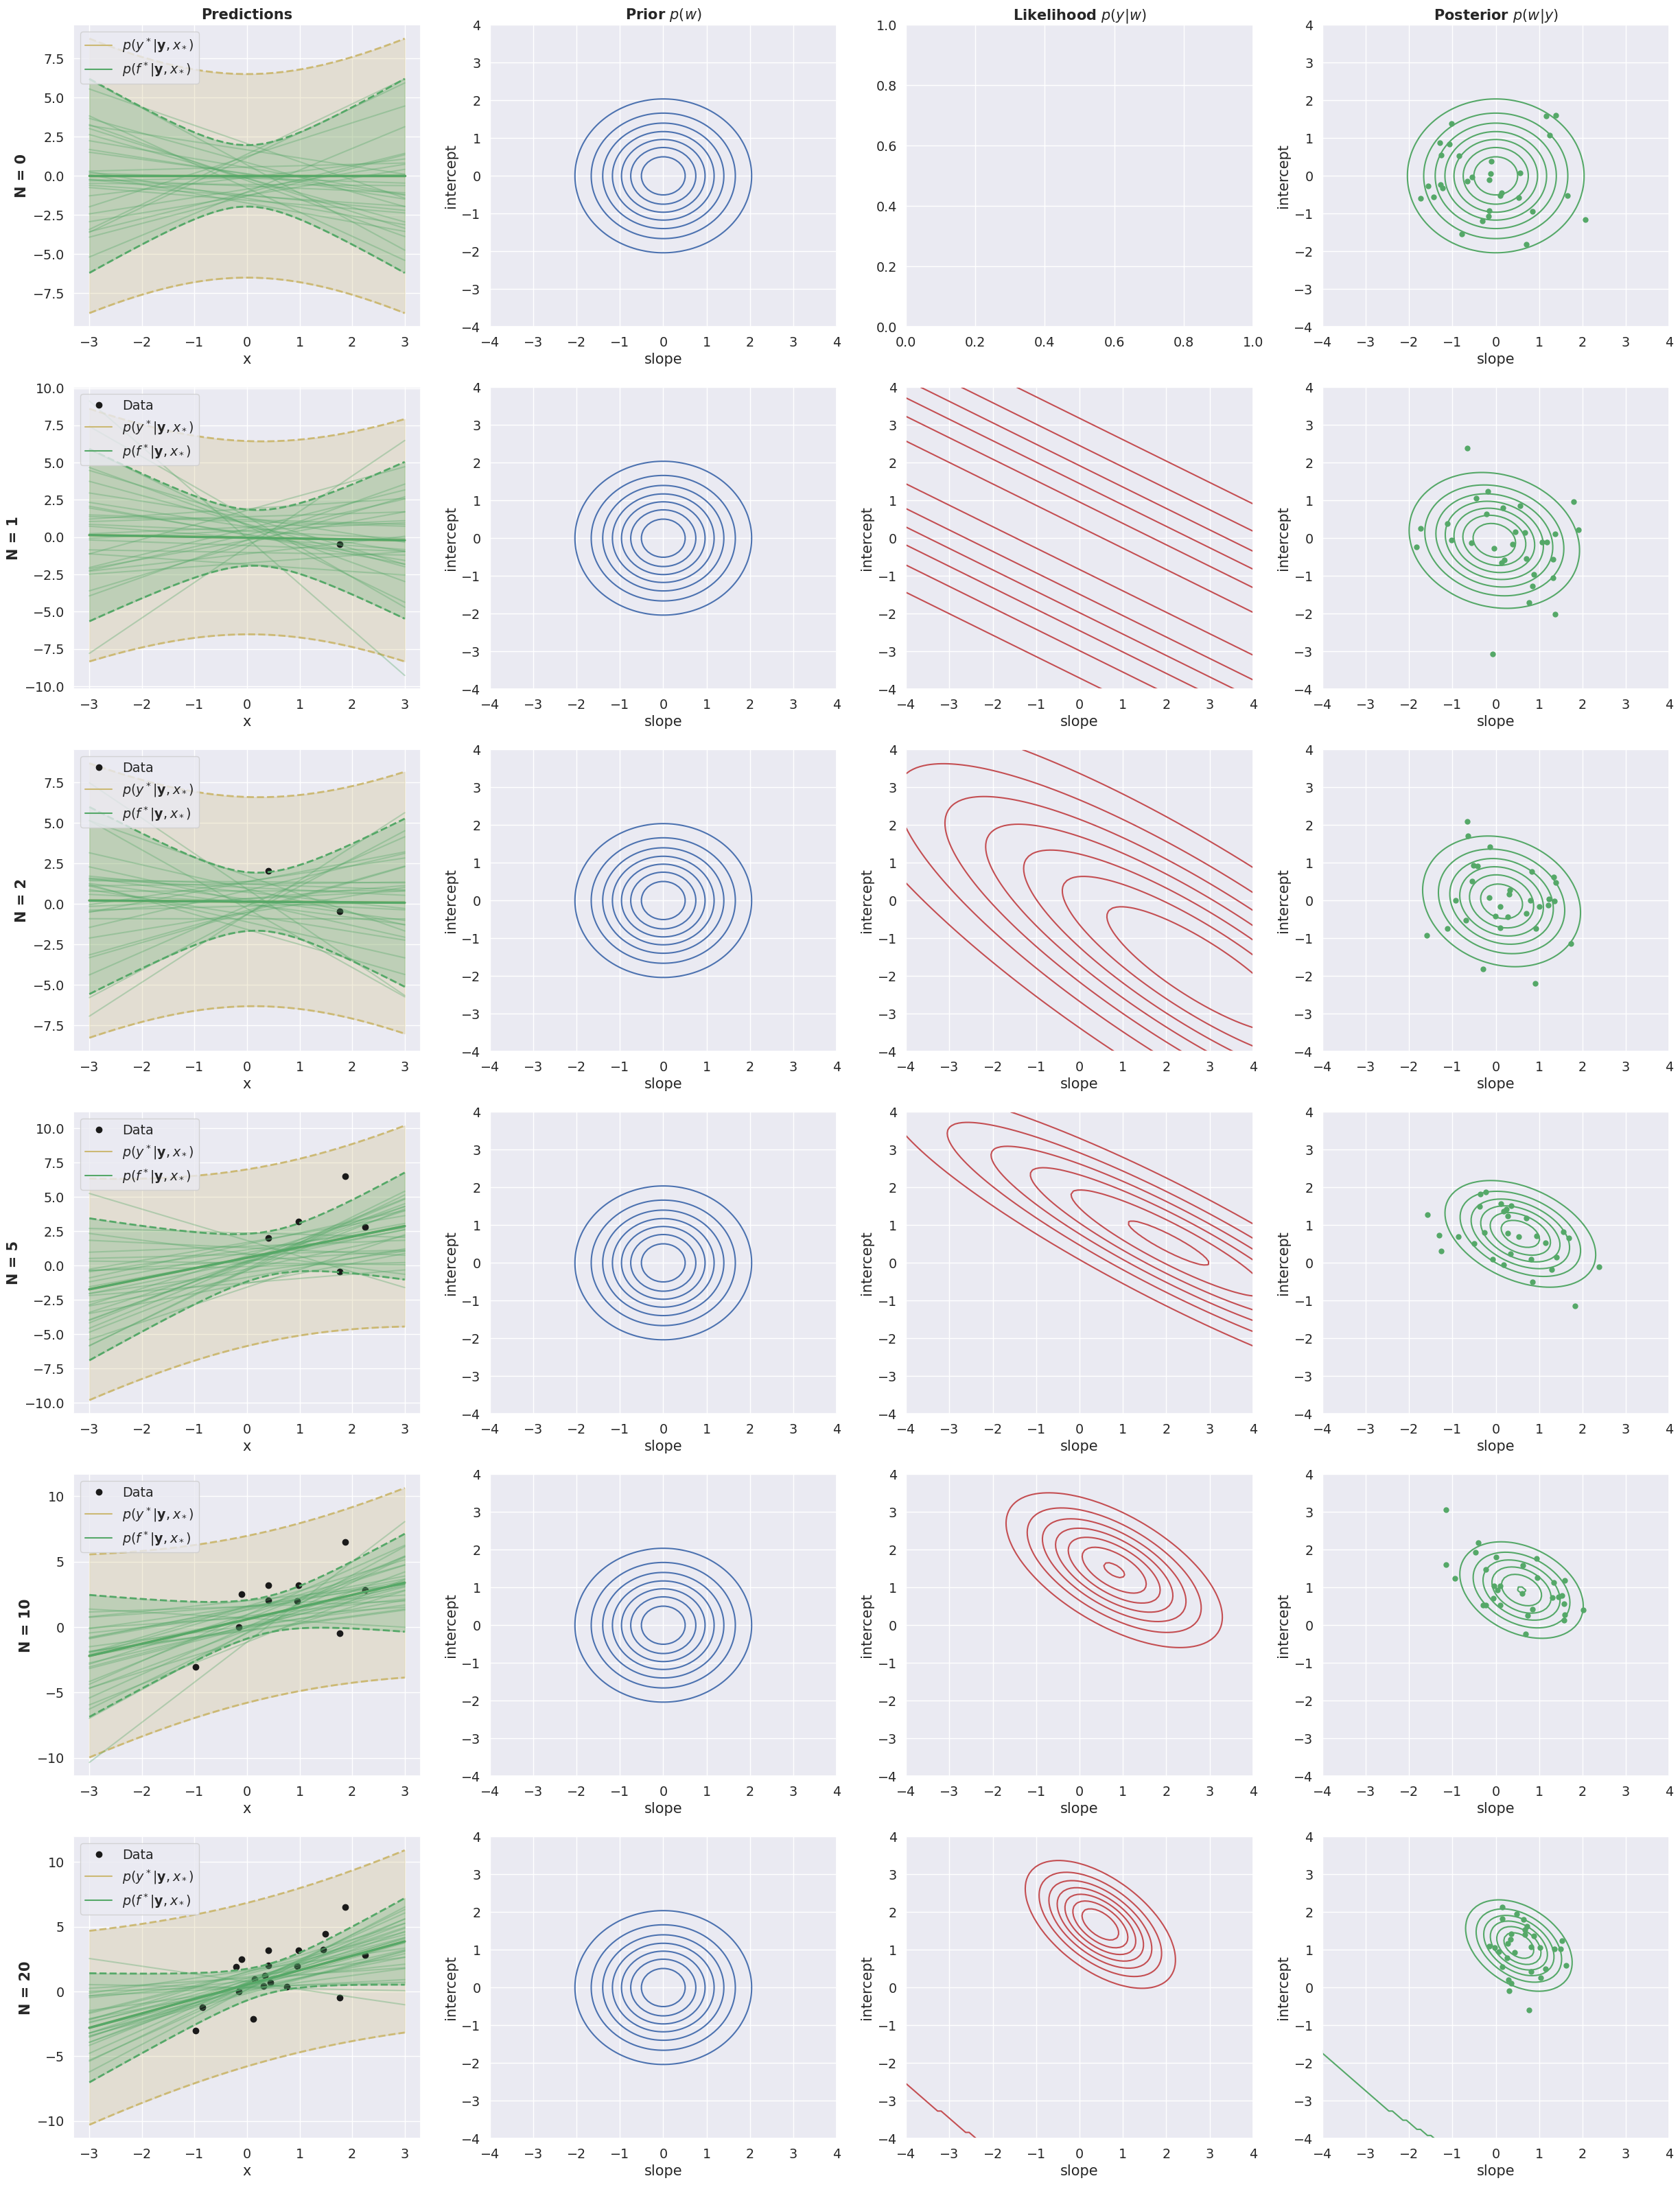

In [8]:
"""
Bayesian Linear Regression Visualization with Progressive Data Updates

This script demonstrates how Bayesian linear regression evolves as more training data
is observed. It shows the progression from prior beliefs through likelihood updates
to posterior distributions, illustrating the fundamental principles of Bayesian learning.

Mathematical Foundation:
- Prior: p(w) = N(w | 0, α⁻¹I) where α controls prior precision
- Likelihood: p(y|w,X) = N(y | Φw, β⁻¹I) where β controls noise precision  
- Posterior: p(w|y,X) = N(w | μₙ, Σₙ) (analytically tractable for linear models)

Key Equations:
- Posterior mean: μₙ = βΣₙΦᵀy
- Posterior covariance: Σₙ = (αI + βΦᵀΦ)⁻¹
- Predictive mean: μ(x*) = μₙᵀφ(x*)
- Predictive variance: σ²(x*) = φ(x*)ᵀΣₙφ(x*) + β⁻¹
"""

def plot_predictions(ax, x, mu, var, color='r', visibility=0.5, label=None):
    """
    Visualize predictive distributions with mean and confidence intervals.
    
    This function plots the predictive mean along with 95% confidence intervals,
    providing a visual representation of model uncertainty.
    
    Mathematical basis:
    - Confidence interval: μ ± 1.96σ (covers ~95% of probability mass)
    - For Gaussian distributions: P(μ - 1.96σ ≤ X ≤ μ + 1.96σ) ≈ 0.95
    
    Args:
        ax: Matplotlib axis object for plotting
        x: Input locations where predictions are made
           Shape: (n_pred, 1) - prediction points
        mu: Predictive mean at each input location  
            Shape: (n_pred, 1) - E[f(x*)] or E[y*]
        var: Predictive variance at each input location
             Shape: (n_pred, 1) - Var[f(x*)] or Var[y*]
        color: Color for the prediction plots
        visibility: Transparency level for confidence bands (0-1)
        label: Legend label for the prediction
    
    Visual elements:
    - Solid line: Predictive mean μ(x)
    - Dashed lines: Confidence bounds μ(x) ± 1.96σ(x)
    - Shaded area: Uncertainty region between bounds
    """
    # Calculate 95% confidence bounds using standard normal quantiles
    # 1.96 is the 97.5th percentile of standard normal (two-tailed 95% CI)
    lower = mu - 1.96 * jnp.sqrt(var)  # Lower confidence bound
    upper = mu + 1.96 * jnp.sqrt(var)  # Upper confidence bound
    
    # Plot predictive mean as solid line
    ax.plot(x, mu, color=color, label=label)
    
    # Plot confidence bounds as dashed lines
    ax.plot(x, lower, color=color, linewidth=2, linestyle='--')
    ax.plot(x, upper, color=color, linewidth=2, linestyle='--')
    
    # Fill area between bounds to show uncertainty region
    ax.fill_between(x.ravel(), lower.ravel(), upper.ravel(), 
                   color=color, alpha=visibility)
    
    # Emphasize the mean with a thicker line
    ax.plot(x, mu, '-', color=color, label="", linewidth=2.5)


# =============================================================================
# EXPERIMENTAL SETUP AND HYPERPARAMETERS
# =============================================================================

# Fix random seed for reproducible results
seed = 123
key = random.PRNGKey(seed)

# Bayesian linear regression hyperparameters
# These control the balance between prior beliefs and data evidence
alpha = 1.0      # Prior precision (inverse variance) for weights
                 # Higher α → stronger prior, more regularization
                 # Prior: p(w) = N(0, α⁻¹I)

beta = 0.1 # 3/4       # Noise precision (inverse variance) for observations  
                 # Higher β → less noise, more trust in data
                 # Likelihood: p(y|w,X) = N(Φw, β⁻¹I)

# Number of posterior samples for visualization
# More samples → smoother visualization of posterior uncertainty
num_samples = 30

# =============================================================================
# PREDICTION GRID AND DESIGN MATRICES
# =============================================================================

# Create dense prediction grid for smooth function visualization
# Shape: (N* = 50, 1) - 50 evenly spaced points from -3 to 3
xpred = jnp.linspace(-3, 3, 50)[:, None]  

# Compute design matrices using basis functions φ(x)
# For linear regression: y = Φw + ε where Φ[i,j] = φⱼ(xᵢ)
Phi_train = design_matrix(xtrain)  # Shape: (n_train (N), n_features (D)) 
Phi_pred = design_matrix(xpred)    # Shape: (N* = 50, n_features (D))
# the design matrix retuns a 2-column feature matrix Φ = [[1, x], [1, x], ...] for linear regression, therefore D = 2

# =============================================================================
# VISUALIZATION: BAYESIAN LEARNING PROGRESSION
# =============================================================================

# Create comprehensive visualization grid
# 6 rows (different dataset sizes) × 4 columns (different views)
fig, axes = plt.subplots(6, 4, figsize=(30, 40))

# Demonstrate learning progression with increasing data
# N = [0, 1, 2, 5, 10, 20] shows transition from prior → posterior
dataset_sizes = [0, 1, 2, 5, 10, 20]



for idx_n, n in enumerate(dataset_sizes):
    """
    For each dataset size n, we visualize four key aspects:
    1. Predictions in data space (function and observation uncertainty)
    2. Prior distribution p(w) in weight space
    3. Likelihood p(y|w) in weight space (if data available)
    4. Posterior distribution p(w|y) in weight space
    """
    
    # Generate fresh random key for this iteration
    key, sample_key = random.split(key)
    
    # =================================================================
    # POSTERIOR COMPUTATION
    # =================================================================
    
    # Create Bayesian linear regression model with first n data points
    # This computes the exact posterior: p(w|y₁:ₙ, x₁:ₙ)
    model = BayesianLinearRegression(
        Phi_train[:n, :],  # Design matrix for first n points: Shape (n, n_features)
        ytrain[:n, :],     # Targets for first n points: Shape (n, 1)  
        alpha,             # Prior precision hyperparameter
        beta               # Noise precision hyperparameter
    )
    
    # Sample from posterior distribution for visualization
    # w ~ p(w|y₁:ₙ, x₁:ₙ) = N(μₙ, Σₙ)
    w_samples = model.generate_posterior_samples(sample_key, num_samples=num_samples)
    # Returns (30, D) array – each row w_i = [a_i, b_i].
    # Shape: (num_samples, n_features)
    
    # Extract weight components for 2D visualization
    # Assumes linear model: f(x) = ax + b (2 parameters)
    a_samples = w_samples[:, 0]  # Slope parameters: Shape (num_samples,)
    b_samples = w_samples[:, 1]  # Intercept parameters: Shape (num_samples,)
    
    # =================================================================
    # PREDICTIVE DISTRIBUTIONS
    # =================================================================
    
    # Compute predictive distribution for latent function f(x*)
    # p(f*|y,X) = N(μf, σ²f) where:
    # μf = μₙᵀφ(x*) (posterior mean prediction)
    # σ²f = φ(x*)ᵀΣₙφ(x*) (epistemic uncertainty only)
    mu_f, var_f = model.predict_f(Phi_pred)
    
    # Compute predictive distribution for noisy observations y*  
    # p(y*|y,X) = N(μy, σ²y) where:
    # μy = μf (same mean as latent function)
    # σ²y = σ²f + β⁻¹ (epistemic + aleatoric uncertainty)
    mu_y, var_y = model.predict_y(Phi_pred)
    
    # =================================================================
    # COLUMN 1: PREDICTIONS IN DATA SPACE
    # =================================================================
    
    # Plot observed training data
    if n > 0:
        axes[idx_n, 0].plot(xtrain[:n, :], ytrain[:n, :], 'k.', 
                           markersize=12, label='Data')
    
    # Plot predictive distribution for observations (includes noise)
    # Yellow represents p(y*|y,X) - what we expect to observe
    plot_predictions(axes[idx_n, 0], xpred, mu_y, var_y, 
                    visibility=0.25, color='y', 
                    label='$p(y^*|\\mathbf{y}, x_*)$')
    
    # Plot predictive distribution for latent function (noise-free)  
    # Green represents p(f*|y,X) - the underlying function
    plot_predictions(axes[idx_n, 0], xpred, mu_f, var_f,
                    visibility=0.25, color='g',
                    label='$p(f^*|\\mathbf{y}, x_*)$')
    
    # Add row label indicating dataset size
    axes[idx_n, 0].set_ylabel('N = %d' % n, fontweight='bold')
    
    # Visualize posterior samples as individual function realizations
    # Each line represents f(x) = aᵢx + bᵢ for sampled (aᵢ, bᵢ)
    for i, (ai, bi) in enumerate(zip(a_samples, b_samples)):
        # Plot individual posterior function samples
        # predict(x, a, b) computes f(x) = ax + b
        axes[idx_n, 0].plot(xpred, predict(xpred, ai, bi), 
                           'g-', alpha=0.35)
    
    axes[idx_n, 0].legend(loc='upper left')
    axes[idx_n, 0].set(xlabel='x')
    
    # =================================================================
    # COLUMN 2: PRIOR DISTRIBUTION p(w)
    # =================================================================
    
    # Visualize prior beliefs about weights before seeing data
    # p(w) = N(0, α⁻¹I) - centered at origin with precision α
    plot_distribution(axes[idx_n, 1], xtrain[:n, :], ytrain[:n, :],
                     density_fun=log_prior, color='b')
    
    # =================================================================  
    # COLUMN 3: LIKELIHOOD p(y|w)
    # =================================================================
    
    # Show likelihood function only when data is available
    if n > 0:
        # Visualize how well different weight values explain observed data
        # p(y|w,X) = N(y | Φw, β⁻¹I) 
        plot_distribution(axes[idx_n, 2], xtrain[:n, :], ytrain[:n, :],
                         density_fun=log_likelihood, color='r')
    
    # =================================================================
    # COLUMN 4: POSTERIOR DISTRIBUTION p(w|y) 
    # =================================================================
    # Show updated beliefs after observing data
    # p(w|y,X) ∝ p(y|w,X)p(w) - combines prior and likelihood
    plot_distribution(axes[idx_n, 3], xtrain[:n, :], ytrain[:n, :],
                     density_fun=log_posterior, color='g')
    
    # Overlay posterior samples to show sampling from computed distribution
    axes[idx_n, 3].plot(a_samples, b_samples, 'g.', markersize=10)

# =============================================================================
# PLOT FORMATTING AND TITLES
# =============================================================================

# Add descriptive titles for each column
axes[0, 0].set_title('Predictions', fontweight='bold')
axes[0, 1].set_title('Prior $p(w)$', fontweight='bold') 
axes[0, 2].set_title('Likelihood $p(y|w)$', fontweight='bold')
axes[0, 3].set_title('Posterior $p(w|y)$', fontweight='bold')


plt.savefig('22.png', bbox_inches='tight', dpi=300)



"""
INTERPRETATION GUIDE:

Row Evolution (N = 0 → 20):
- N=0: Pure prior, maximum uncertainty in predictions
- N=1: First data point constrains likelihood, slight posterior update  
- N=2: Linear trend begins to emerge, reduced uncertainty
- N=5: Clear trend established, good confidence in slope
- N=10: Well-defined function, tight confidence intervals
- N=20: High confidence, minimal remaining uncertainty

Column Interpretations:
1. Predictions: Shows how model uncertainty decreases and accuracy improves
2. Prior: Remains constant - our initial beliefs about plausible weights
3. Likelihood: Becomes more peaked - data increasingly constrains weights  
4. Posterior: Evolves from prior toward likelihood - Bayesian learning in action

Key Observations:
- Green bands (f*) are always tighter than yellow bands (y*) due to observation noise
- Posterior samples (green dots) concentrate as more data arrives
- Individual function samples (thin green lines) show range of plausible functions
- Weight space visualization reveals the geometric interpretation of Bayesian updates
"""

_____


| Symbol         | Code slice         | Shape      | What it means                                                                                                                                                                                                                                                                                   |
| -------------- | ------------------ | ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  $\Phi_n$      | `Phi_train[:n, :]` | **(n, D)** | **Python indexing:** `:` after the comma means “all columns”; `:n` before the comma means “rows 0 up to (but not including) n”.<br>So we take **the first *n*** training examples from the full design matrix `Phi_train` (shape $(N,D)$) while keeping every column (all $D$ basis functions). |
|  $\mathbf y_n$ | `ytrain[:n, :]`    | **(n, 1)** | Same slice on the **target vector**: select the first *n* rows of `ytrain` (originally $(N,1)$), keep the single column.                                                                                                                                                                        |
____

| Slice | Meaning                       | Example result on a 1D range `[0,1,2,3,4]` |
| ----- | ----------------------------- | ------------------------------------------ |
| `:n`  | from start *up to* n‑1        | `a[:3] → [0,1,2]`                          |
| `m:`  | from m *to the end*           | `a[2:] → [2,3,4]`                          |
| `:`   | *all* indices along that axis | `a[:] → [0,1,2,3,4]`                       |


_____

>Applied to a 2‑D array, :n, : means “first n rows, all columns”; hence the shapes (n,D)(n,D) and (n,1)(n,1).

____

| symbol                  | code slice         | shape   | equation      |
| ----------------------- | ------------------ | ------- | ------------- |
| `Φ_n`                   | `Phi_train[:n, :]` | `(n,D)` | design matrix |
| `y_n`                   | `ytrain[:n, :]`    | `(n,1)` | target vector |
| **Posterior precision** | `A = αI + β ΦᵀΦ`   | `(D,D)` | $S_N^{-1}$    |
| **Posterior cov.**      | `S = A^{-1}`       | `(D,D)` | $S_N$         |
| **Posterior mean**      | `m = β S Φᵀ y`     | `(D,1)` | $m_N$         |


____


##### Predictive mean & variance 

```python
# Predictive mean and variance for f_* and y_*
mu_f, var_f = model.predict_f(Phi_pred)
mu_y, var_y = model.predict_y(Phi_pred)
```


| variable | shape   | formula                                |
| -------- | ------- | -------------------------------------- |
| `mu_f`   | `(N*,)` | μ\*(x) = Φ\* m\_N                      |
| `var_f`  | `(N*,)` | diag(Φ\* S\_N Φ\*ᵀ)                    |
| `mu_y`   | `(N*,)` | same as `mu_f`                         |
| `var_y`  | `(N*,)` | `var_f + β⁻¹`  ⇔ σ²(x\*) in cheatsheet |

_____

> Broadcasting note:
> 
> Phi_pred @ model.S @ Phi_pred.T produces an (N*, N*) covariance matrix;
> 
> jnp.diag extracts its diagonal into a length‑N* vector, so no explicit loop is needed.

_____


| Symbol         | Code slice         | Shape      | What it means                                                                                                                                                                                                                                                                                   |
| -------------- | ------------------ | ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|  $\Phi_n$      | `Phi_train[:n, :]` | **(n, D)** | **Python indexing:** `:` after the comma means “all columns”; `:n` before the comma means “rows 0 up to (but not including) n”.<br>So we take **the first *n*** training examples from the full design matrix `Phi_train` (shape $(N,D)$) while keeping every column (all $D$ basis functions). |
|  $\mathbf y_n$ | `ytrain[:n, :]`    | **(n, 1)** | Same slice on the **target vector**: select the first *n* rows of `ytrain` (originally $(N,1)$), keep the single column.                                                                                                                                                                        |
____

| Slice | Meaning                       | Example result on a 1D range `[0,1,2,3,4]` |
| ----- | ----------------------------- | ------------------------------------------ |
| `:n`  | from start *up to* n‑1        | `a[:3] → [0,1,2]`                          |
| `m:`  | from m *to the end*           | `a[2:] → [2,3,4]`                          |
| `:`   | *all* indices along that axis | `a[:] → [0,1,2,3,4]`                       |


_____

>Applied to a 2‑D array, :n, : means “first n rows, all columns”; hence the shapes (n,D)(n,D) and (n,1)(n,1).

____

| symbol                  | code slice         | shape   | equation      |
| ----------------------- | ------------------ | ------- | ------------- |
| `Φ_n`                   | `Phi_train[:n, :]` | `(n,D)` | design matrix |
| `y_n`                   | `ytrain[:n, :]`    | `(n,1)` | target vector |
| **Posterior precision** | `A = αI + β ΦᵀΦ`   | `(D,D)` | $S_N^{-1}$    |
| **Posterior cov.**      | `S = A^{-1}`       | `(D,D)` | $S_N$         |
| **Posterior mean**      | `m = β S Φᵀ y`     | `(D,1)` | $m_N$         |


____


##### Predictive mean & variance 

```python
# Predictive mean and variance for f_* and y_*
mu_f, var_f = model.predict_f(Phi_pred)
mu_y, var_y = model.predict_y(Phi_pred)
```


| variable | shape   | formula                                |
| -------- | ------- | -------------------------------------- |
| `mu_f`   | `(N*,)` | μ\*(x) = Φ\* m\_N                      |
| `var_f`  | `(N*,)` | diag(Φ\* S\_N Φ\*ᵀ)                    |
| `mu_y`   | `(N*,)` | same as `mu_f`                         |
| `var_y`  | `(N*,)` | `var_f + β⁻¹`  ⇔ σ²(x\*) in cheatsheet |

_______




In the figure above, the first column shows the data as well as the predictive distribution with 95% intervals. Each of the green lines corresponds to the function $f(x)$ for different posterior samples for $\mathbf{w}$. The columns 2, 3, and 4 show the prior, likelihood and posterior, respectively. Study the code and the plots above and answer the following questions:

**Task 3.2**: What happens to prior, likelihood and posterior as the number of samples $N$ increases? [**Discussion question**]



**Task 3.3**: What happens to the predictions if you keep $\beta = \frac{3}{4}$ and increase $\alpha$, e.g. to $\alpha = 100$ or $\alpha = 1000$? Why? [**Discussion question**]



**Task 3.4**: Set $\alpha$ to $\alpha = 1$ again. What happens if you decrease $\beta$, e.g. to $\beta = 0.1$? Why? [**Discussion question**]


**Task 3.5**: The variance of the predictive distribution $p(y_*|\mathbf{y}, \mathbf{x}_*)$ contains two components. Describe the two components in your own words and relate them to epistemic and aleatoric uncertainty. [**Discussion question**]


**Task 3.6**: As we get more and more data, the variance of the posterior distribution of $\mathbf{w}$ goes to zero. What happens to the variance of $p(y_*|\mathbf{y}, \mathbf{x}_*)$, $p(y^*|\mathbf{x}^*, \mathbf{w})$, and $p(f_*|\mathbf{y}, \mathbf{x}_*)$ as $N$ increases? To answer this, fix $\alpha = \beta = 1$ and consider the point $x^* = 1$. Plot the following three variances: the posterior predictive variance of $y^*$, the conditional variance of $y^*$ given $\mathbf{w}$ and posterior variance of $f^*$ as a function as size of the training set, i.e. for $N = \left\lbrace 0, 1, 2, .., 30 \right\rbrace$. Compare the plots to your findings above.

N =  0,   Var[f*] = 2.0000,   Var[y*] = 3.0000
N =  1,   Var[f*] = 0.5054,   Var[y*] = 1.5054
N =  2,   Var[f*] = 0.3620,   Var[y*] = 1.3620
N =  5,   Var[f*] = 0.1754,   Var[y*] = 1.1754
N = 10,   Var[f*] = 0.1009,   Var[y*] = 1.1009
N = 20,   Var[f*] = 0.0609,   Var[y*] = 1.0609


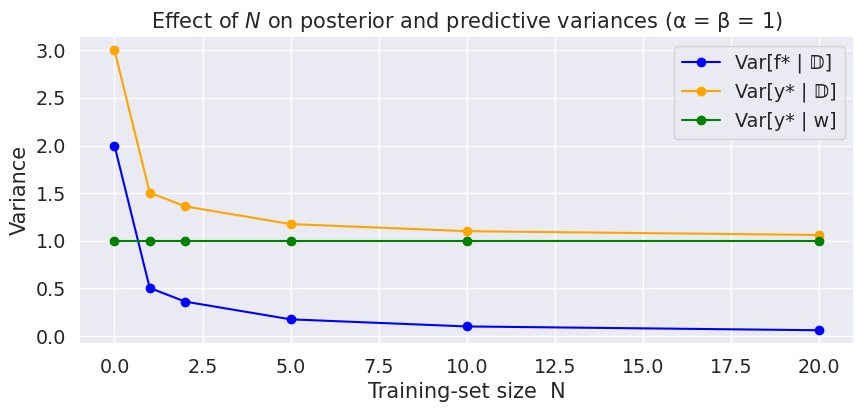

In [28]:
# ------------------------------------------------------------
# 0.  HYPER‑PARAMETERS  (Bishop PRML §3.5 notation)
#     α   : prior precision  (inverse variance of p(w))
#     β   : noise precision  (inverse variance of ε)
# ------------------------------------------------------------
alpha = 1.0
beta  = 1.0           # keep both fixed as requested

# ------------------------------------------------------------
# 1.  TRAIN / TEST DATA  (assume these exist in the workspace)
#     xtrain, ytrain must be 1‑D arrays of equal length.
#     design_matrix(x) returns Φ(x) row‑wise.
# ------------------------------------------------------------
Phi_train = design_matrix(xtrain)                   # Φ      ∈ ℝ^{N×D}
x_star     = jnp.array([1.0])                       # x*     ∈ ℝ
Phi_star   = design_matrix(x_star)                  # φ*ᵀ    ∈ ℝ^{1×D}

# ------------------------------------------------------------
# 2.  DATA‑SET SIZES WE WANT TO EXPLORE
#     NB: Use the *values* in dataset_sizes, not the loop index.
# ------------------------------------------------------------
dataset_sizes = [0, 1, 2, 5, 10, 20]               # you can extend to range(31)

# ------------------------------------------------------------
# 3.  ARRAYS THAT WILL COLLECT VARIANCES
#     f_star_list : Var[f* | 𝔻]          = φ*ᵀ S φ*
#     y_star_list : Var[y* | 𝔻]          = φ*ᵀ S φ* + β⁻¹
#     cond_noise  : Var[y* | w,true w]   = β⁻¹  (constant)
# ------------------------------------------------------------
var_f_star_list   = []
var_y_star_list   = []
cond_noise_levels = []                             # will just repeat 1/β

# ------------------------------------------------------------
# 4.  MAIN LOOP OVER DIFFERENT TRAIN‑SET SIZES
# ------------------------------------------------------------
for N in dataset_sizes:
    # --- 4.1  SELECT FIRST N SAMPLES -------------------------
    #         Φ_N  ∈ ℝ^{N×D}, y_N ∈ ℝ^{N×1}
    Phi_N = Phi_train[:N, :]
    y_N   = ytrain[:N, :]

    # --- 4.2  FIT BLR MODEL  (Eqs. 3.53–3.54 in Bishop) -----
    model = BayesianLinearRegression(Phi_N, y_N, alpha=alpha, beta=beta)

    # --- 4.3  PREDICTIVE VARIANCES ---------------------------
    #
    #     predict_f returns (μ_f , σ_f²)   for latent function f*
    #     predict_y returns (μ_y , σ_y²)   for noisy target y*
    #
    #     We only need the variance (index 1 of the tuple).
    #     The result has shape (1,) → use .item() or .ravel()[0].
    # ---------------------------------------------------------
    mu_f, var_f = model.predict_f(Phi_star)        # σ_f² = φ*ᵀ S φ*
    mu_y, var_y = model.predict_y(Phi_star)        # σ_y² = σ_f² + β⁻¹

    var_f_star_list.append(var_f.ravel()[0])       # same as var_f[0]
    var_y_star_list.append(var_y.ravel()[0])

    # --- 4.4  CONDITIONAL VAR(y* | w)  -----------------------
    #     Given weights, the only randomness is ε ~ N(0, β⁻¹).
    #     Hence Var[y* | w] = β⁻¹, independent of N.
    # ---------------------------------------------------------
    cond_noise_levels.append(1.0 / beta)

    # Optional progress print
    print(f"N = {N:>2},   Var[f*] = {var_f_star_list[-1]:.4f},   Var[y*] = {var_y_star_list[-1]:.4f}")

# ------------------------------------------------------------
# 5.  PLOT RESULTS
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(dataset_sizes, var_f_star_list, 'o-', label='Var[f* | 𝔻]',      color='blue')
ax.plot(dataset_sizes, var_y_star_list, 'o-', label='Var[y* | 𝔻]',      color='orange')
ax.plot(dataset_sizes, cond_noise_levels, 'o-', label='Var[y* | w]',    color='green')

ax.set_xlabel('Training‑set size  N')
ax.set_ylabel('Variance')
ax.set_title(r'Effect of $N$ on posterior and predictive variances (α = β = 1)')
ax.legend()
plt.show()

**Task 3.7**: Compute the prior mean and variance $f(x^*) = \phi(x^*)^T \bm{w} = a + b x^*$?*. Use the results to explain why the variance of both the posterior distribution of $f(x^*)$ and the variance of the posterior predictive distribution of $y(x^*)$ are smallest for $x^* = 0$ and both increase with $|x^*|$ for $N = 0$.




In [59]:
x_star = jnp.array([0])
y = jnp.array([0]).reshape(-1, 1)

Phi = design_matrix(x_star)

model_2 = BayesianLinearRegression(Phi, y, alpha=1.0, beta=1.0)
m, S = model_2.m.ravel(), model_2.S
print(f"Posterior mean: {m.ravel()}")
print(f"Posterior uncertainty (diagonal of S): {jnp.diag(S)}")

# prior latent f 

mu_f, var_f = model_2.predict_f(Phi)
print(f"Predictive mean of f: {mu_f.ravel()}")
print(f"Predictive variance of f: {var_f.ravel()}") 

# prior y
mu_y, var_y = model_2.predict_y(Phi)
print(f"Predictive mean of y: {mu_y.ravel()}")
print(f"Predictive variance of y: {var_y.ravel()}")




Posterior mean: [0. 0.]
Posterior uncertainty (diagonal of S): [0.5 1. ]
Predictive mean of f: [0.]
Predictive variance of f: [0.5]
Predictive mean of y: [0.]
Predictive variance of y: [1.5]


# !

prior mean w = [0. 0.]
prior cov  w = [[1. 0.]
 [0. 1.]]
Prior   f* mean = 0.0,  variance = 1.0
Prior   y* mean = 0.0,  variance = 2.0
Sample variance f* ≈ 0.99273413


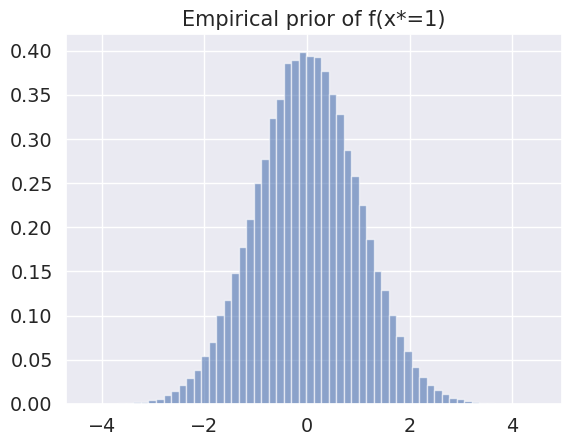

In [60]:
# ------------------------------------------------------------
# 0.  Create a tiny "empty–data" model so that
#     posterior == prior (because Φ, y have zero rows)
# ------------------------------------------------------------
D        = 2                              # number of weights (a, b)
Phi_nil  = jnp.zeros((0, D))              # shape (N=0, D)
y_nil    = jnp.zeros((0, 1))
alpha    = 1.0                            # prior precision
beta     = 1.0                            # noise precision

prior_model = BayesianLinearRegression(Phi_nil, y_nil, alpha, beta)

# ---------- 1. PRIOR OVER WEIGHTS  --------------------------
prior_mean_w = jnp.zeros((D, 1))          # E[w]        = 0
prior_cov_w  = (1/alpha) * jnp.eye(D)     # Var[w]      = α⁻¹ I

print("prior mean w =", prior_mean_w.ravel())
print("prior cov  w =", prior_cov_w)

# ---------- 2. PRIOR DISTRIBUTION OF f(x*) ------------------
def prior_f_statistics(Phi_star, alpha):
    """Return (mean, variance) of f* under the prior."""
    mu_f  = 0.0                                           # because E[w]=0
    var_f = (1/alpha) * (Phi_star @ Phi_star.T).item()    # φ*ᵀ α⁻¹I φ*
    return mu_f, var_f

x_star   = 0.0
Phi_star = design_matrix(jnp.array([x_star]))             # shape (1,D)
mu_f, var_f = prior_f_statistics(Phi_star, alpha)
print(f"Prior   f* mean = {mu_f},  variance = {var_f}")

# ---------- 3. PRIOR PREDICTIVE DISTRIBUTION OF y* ----------
mu_y = mu_f
var_y = var_f + 1/beta                                    # add noise β⁻¹
print(f"Prior   y* mean = {mu_y},  variance = {var_y}")

# ---------- 4.  SANITY CHECK WITH SAMPLES -------------------
import matplotlib.pyplot as plt
key   = random.PRNGKey(0)
w_smp = prior_model.generate_prior_samples(key, 100_000)  # (100k, D)
f_smp = (Phi_star @ w_smp.T).ravel()                      # vector length 100k
print("Sample variance f* ≈", f_smp.var())                # ~ var_f

plt.hist(f_smp, bins=60, density=True, alpha=.6)
plt.title("Empirical prior of f(x*=1)"); plt.show()


### Part 4:  Modelling the number of Airline passengers

Now we will apply Bayesian linear regression to model the number of monthly airline passengers (in thousands) in the period from 1949-1960. The values $(x_n, y_n)$ denote the time in months since the beginning of 1949 and the number monthly number of passangers, respectively.

So far, we have assumed that the hyperparameters $\alpha$ and $\beta$ of the model were fixed and known, but in practice, we almost always need to estimate them from data (or impose a prior on them and marginalize over them). As long as the number of hyperparameters is small, we can always rely on **cross-validation**. However, often the Bayesian framework offers a way to estimate these parameters based on the training set alone as follows.

The ***evidence approximation*** suggests that we can simply choose the hyperparameters $\alpha, \beta$ that maximizes the marginal likelihood of the model

$$\begin{align*}
\alpha^*, \beta^* = \arg\max\limits_{\alpha, \beta} \ln p(\mathbf{y}|\alpha, \beta),
\end{align*}$$

where $p(\mathbf{y}|\alpha, \beta) = \mathcal{N}(\mathbf{y}|\bm{0}, \alpha^{-1}\Phi^T \Phi + \beta^{-1}\mathbf{I})$ is the marginal likelihood of the model. This is also often referred to as **maximum likelihood type II estimation**. We could also easily "upgrade" this to **MAP type II estimation** by imposing a prior on $p(\alpha, \beta)$, i.e.

$$\begin{align*}
\alpha^*, \beta^* = \arg\max\limits_{\alpha, \beta} \ln p(\mathbf{y}|\alpha, \beta)p(\alpha, \beta).
\end{align*}$$

However, in this exercise we will use a uniform prior on $\alpha$ and $\beta$, i.e. $p(\alpha, \beta) \propto 1$, in which case the two estimators will give the same results.

Note that since both $\alpha >0 $ and $\beta > 0$ are strictly positive parameters (why?), we optimize $\tilde{\alpha} = \log \alpha$ and $\tilde{\beta} = \log \beta$ to enforce positivity on $\alpha$ and $\beta$.
We rely on **JaX** for gradient-based optimization using automatic differentiation and use the standard optimizer in scipy.


Let's load the data and plot the data.


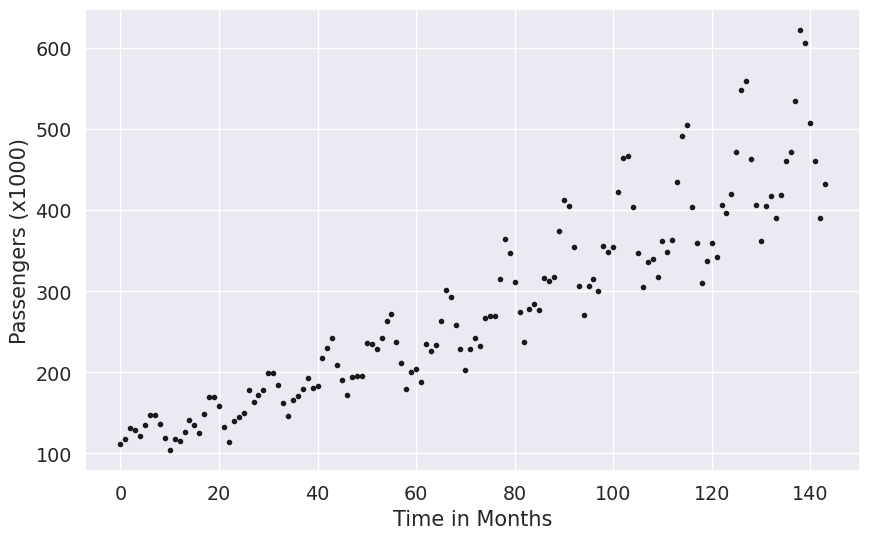

In [62]:
data = pd.read_csv('./AirPassengers.csv')
months = jnp.arange(0, len(data))[:, None]
passengers = jnp.array(data['#Passengers'].values)[:, None]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(months, passengers, 'k.')
ax.set_xlabel('Time in Months')
ax.set_ylabel('Passengers (x1000)');

Since the number of passengers is a strictly positive quantity, we can often get better results by modelling the logarithm of the number of passengers instead.  We also split the dataset into a training and test set

N      = 144
Ntrain = 110
Ntest  = 34


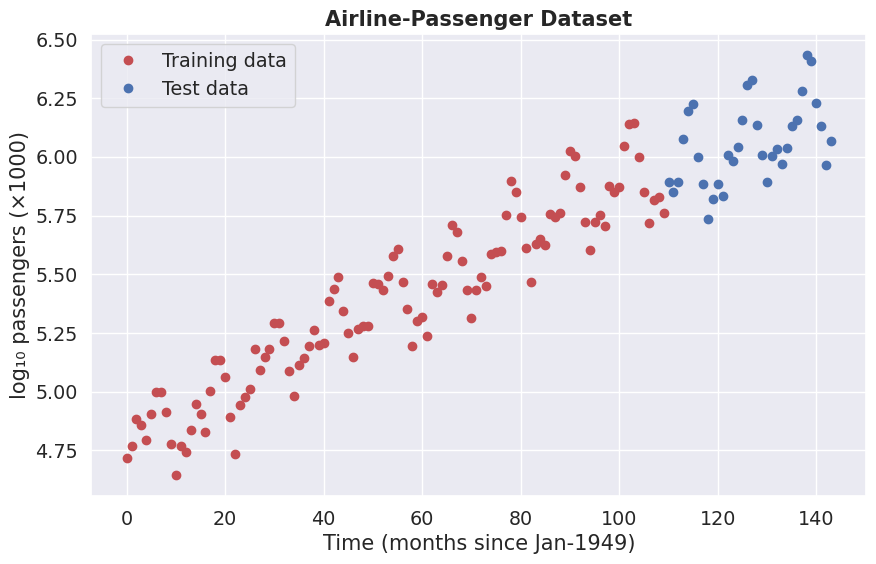

In [65]:
###############################################################################
# Data preparation for the airline‑passenger BLR experiment
#
# Assumptions
# -----------
# • `passengers`  – 1‑D NumPy / JAX array of length 144
#                   raw monthly passenger counts 1949‑01 … 1960‑12.
# • `months`      – list/array of length 144 with the same ordering
#                   (only used to define the x‑axis here).
#
# Shapes in this script
# ---------------------
# passengers : (N,)         where N = 144
# y          : (N,)         log‑transformed passengers
# x          : (N,)         month index 0 … 143
# xtrain     : (Ntrain,)    first 110 months   (≈ 1949‑01 … 1958‑02)
# ytrain     : (Ntrain,)    matching log counts
# xtest      : (Ntest,)     remaining 34 months (≈ 1958‑03 … 1960‑12)
# ytest      : (Ntest,)     matching log counts
###############################################################################

import jax.numpy as jnp
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1.  Log‑transform the target variable
#     -------------------------------
#     Rationale: the raw counts grow exponentially;
#     taking log stabilises variance and lets a *linear* model
#     capture a multiplicative trend.
# ------------------------------------------------------------------
y = jnp.log(passengers)             # shape (N,)

# ------------------------------------------------------------------
# 2.  Train / test split
#     ------------------
#     • We hold out the final 34 months for assessing extrapolation.
# ------------------------------------------------------------------
N       = len(y)                    # total number of samples, 144
Ntrain  = 110                       # arbitrary but gives ~2.5 yrs hold‑out
Ntest   = N - Ntrain                # 34

x = jnp.arange(len(months))         # month index [0, 1, …, 143], shape (N,)
xtrain = x[:Ntrain]                 # first 110 indices, shape (Ntrain,)
xtest  = x[Ntrain:]                 # last 34 indices,  shape (Ntest,)

ytrain = y[:Ntrain]                 # log counts for training set
ytest  = y[Ntrain:]                 # log counts for test set

print(f"N      = {N}")              # 144
print(f"Ntrain = {Ntrain}")         # 110
print(f"Ntest  = {Ntest}")          # 34

# ------------------------------------------------------------------
# 3.  Visualization helper
#     --------------------
#     • Red circles = training data
#     • Blue circles = test data
# ------------------------------------------------------------------
def plot_data(ax):
    ax.plot(xtrain, ytrain, 'ro', label='Training data')   # red   • shape (110,)
    ax.plot(xtest,  ytest,  'bo', label='Test data')       # blue  • shape (34,)
    ax.set_xlabel('Time (months since Jan‑1949)')
    ax.set_ylabel('log₁₀ passengers (×1000)')
    ax.set_title('Airline‑Passenger Dataset', fontweight='bold')
    ax.legend()

# ------------------------------------------------------------------
# 4.  Draw the figure
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
plot_data(ax)
plt.show()


To measure the quality of the fit, we use the  **expected log predictive densities (ELPD)** for the training and test sets

\begin{align}
\text{ELPD} = \frac{1}{M}\sum_{i=1}^M \ln p(y^*_i|\mathbf{y}, \mathbf{x}^*_i),
\end{align}

where $p(y^*_i|\mathbf{y}, \mathbf{x}^*_i)$ is the posterior predictive distribution for observation $y^*_i$ in some dataset $\mathcal{D}_* = \left\lbrace \mathbf{x}^*_i, y^*_i \right\rbrace_{i=1}^M$. In contrast to simply reporting the mean square errors or similar, the ELPD also takes the uncertainty into account.

Optimised α  = 0.0872501
Optimised β  = 58.942074


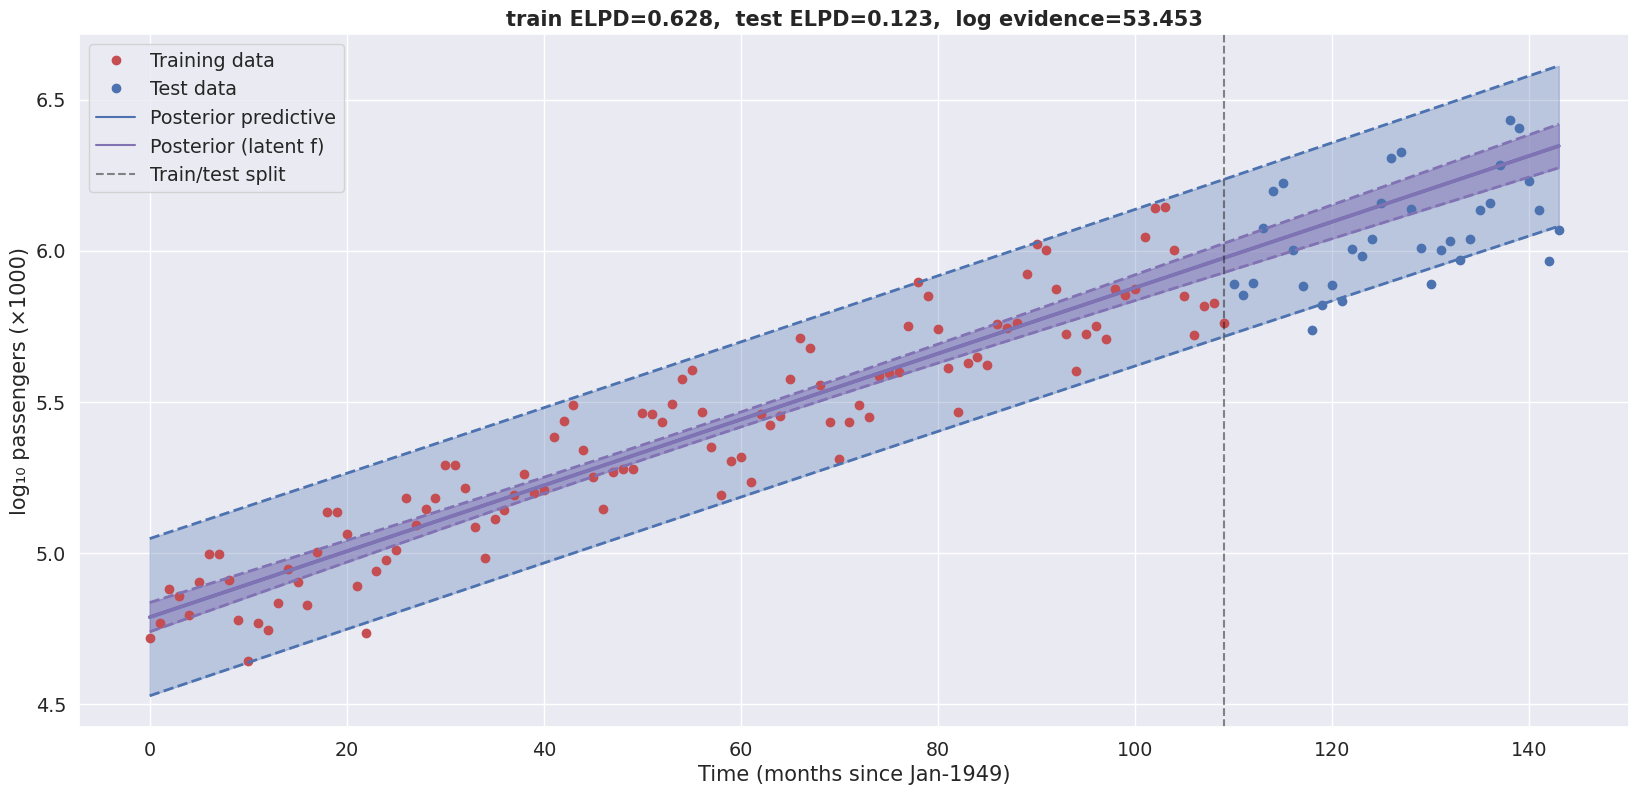

In [105]:
def compute_elpd(y, mu, s2):
    """
    y is a vector of observed values, and mu and s2 are the mean and variances of the posterior predictive distribution, respectively. 
    Expected Log Predictive Density (ELPD)                 (Gelman et al.)
    -------------------------------------------------------------------
    Arguments
      y   : observed values, shape (N,) or (N,1)
      mu  : predictive mean  E[y* | D], same shape
      s2  : predictive variance Var[y* | D], same shape

    Returns
      scalar = average over data points of log p(y_n | D)
               (higher is better; -∞ is worst)
    """
    return jnp.mean(log_npdf(y.ravel(), mu.ravel(), s2.ravel()))
    # .ravel() makes them 1‑D, avoiding shape mismatches

# Creates design matrix Phi based on input
def design_matrix(x):
    """
    Φ(x) = [1, x, x²]      ← quadratic trend basis
    Feel free to uncomment seasonal cosine terms etc.
    """
    return jnp.column_stack((jnp.ones(len(x)), x)) 
    #return jnp.column_stack((jnp.ones(len(x)), x, x**2))
    #return jnp.column_stack((jnp.ones(len(x)), x,   x**2, jnp.cos(2*jnp.pi*x/12))) 


# ---------------------------------------------------------------------
# 1. PREPARE TRAIN / TEST / PREDICTION GRIDS
# ---------------------------------------------------------------------
xpred = jnp.linspace(0, 143, 500)       # 500 evenly‑spaced months for smooth curve

Phi_train = design_matrix(xtrain)       # Φ_train ∈ ℝ^{N_train×D}
Phi_test  = design_matrix(xtest)        # Φ_test  ∈ ℝ^{N_test×D}
Phi_pred  = design_matrix(xpred)        # Φ_pred  ∈ ℝ^{500×D}

# ---------------------------------------------------------------------
# 2. FIT BLR MODEL  (α=β=1 here; could call .optimize_hyperparameters())
# ---------------------------------------------------------------------
model = BayesianLinearRegression(Phi_train, ytrain,
                                 alpha=1.0, beta=1.0)

# If you want Type‑II ML evidence optimisation uncomment:
model.optimize_hyperparameters()

print("Optimised α  =", model.alpha)   # prior variance of w
print("Optimised β  =", model.beta)    # noise precision (1/σ²)



logZ = model.log_marginal_likelihood     # log evidence  (eq. 3.86 Bishop)

# ---------------------------------------------------------------------
# 3. PREDICTIVE CURVES FOR PLOTTING
# ---------------------------------------------------------------------
# (i) latent function f(x)            μ_f , σ_f²   (eq. 3.58)
ypred_mu, ypred_s2 = model.predict_f(Phi_pred)

# (ii) noisy observations y = f + ε   μ_y , σ_y²   (σ_y² = σ_f² + β⁻¹)
tpred_mu, tpred_s2 = model.predict_y(Phi_pred)

# ---------------------------------------------------------------------
# 4. METRICS ON TRAIN & TEST SPLITS
# ---------------------------------------------------------------------
ytrain_mu, ytrain_s2 = model.predict_y(Phi_train)
ytest_mu,  ytest_s2  = model.predict_y(Phi_test)

train_elpd = compute_elpd(ytrain, ytrain_mu, ytrain_s2)
test_elpd  = compute_elpd(ytest,  ytest_mu,  ytest_s2)

# ---------------------------------------------------------------------
# 5. PLOTTING ROUTINE
#    Helper functions plot_data()  and plot_predictions()
#    are assumed to already exist in the notebook.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(20, 9))

plot_data(ax)                                              # raw series
plot_predictions(ax, xpred, tpred_mu, tpred_s2,
                 color='b', label='Posterior predictive', visibility=0.3)
plot_predictions(ax, xpred, ypred_mu, ypred_s2,
                 color='m', label='Posterior (latent f)')

ax.set_title(
    f"train ELPD={train_elpd:.3f},  test ELPD={test_elpd:.3f},  "
    f"log evidence={logZ:.3f}",
    fontweight='bold'
)
ax.axvline(xtrain[-1], color='k', linestyle='--', alpha=0.5,
           label='Train/test split')

ax.legend()
plt.show()


**Task 4.1**: Run the code with $\alpha = 10$ and $\beta = 1$ as initial values. Comment on the quality of the fit. Note the values of the negative log likelihood for the training and test set.


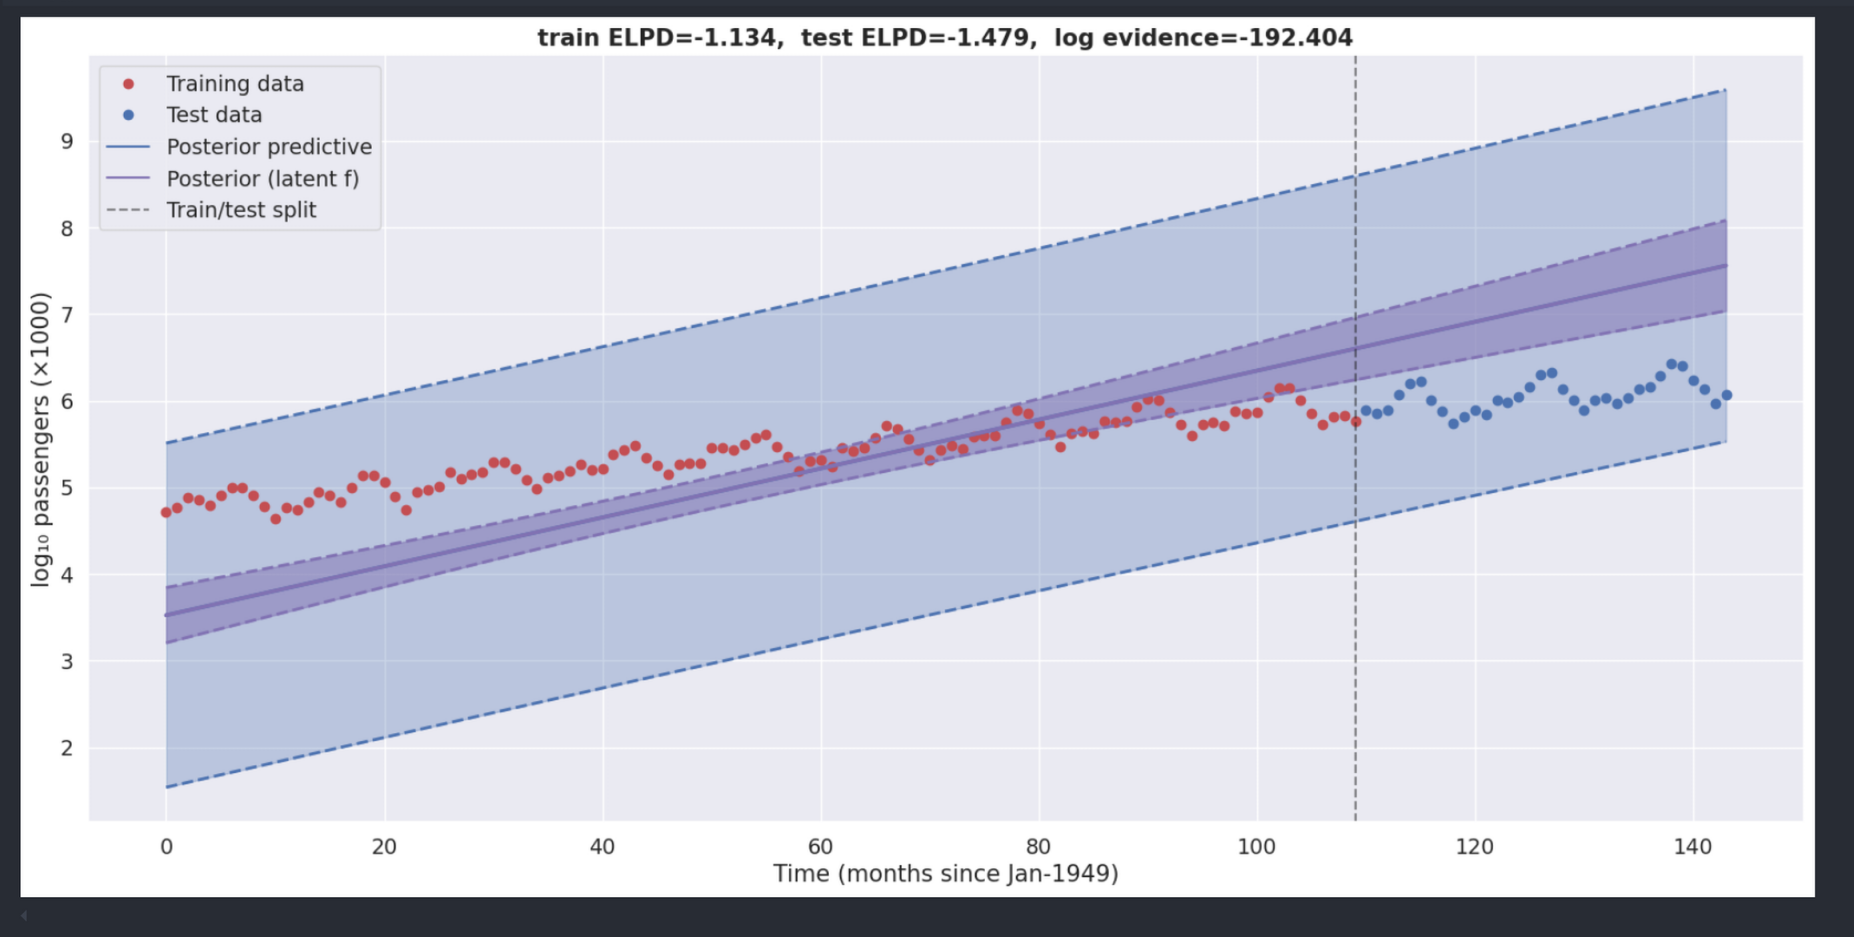


**Task 4.2**: Estimate $\alpha, \beta$ by optimizing the marginal likelihood by uncommenting the line, which calls the function *optimize_hyperparameters()*. Report the estimates for $\alpha$ and $\beta$.

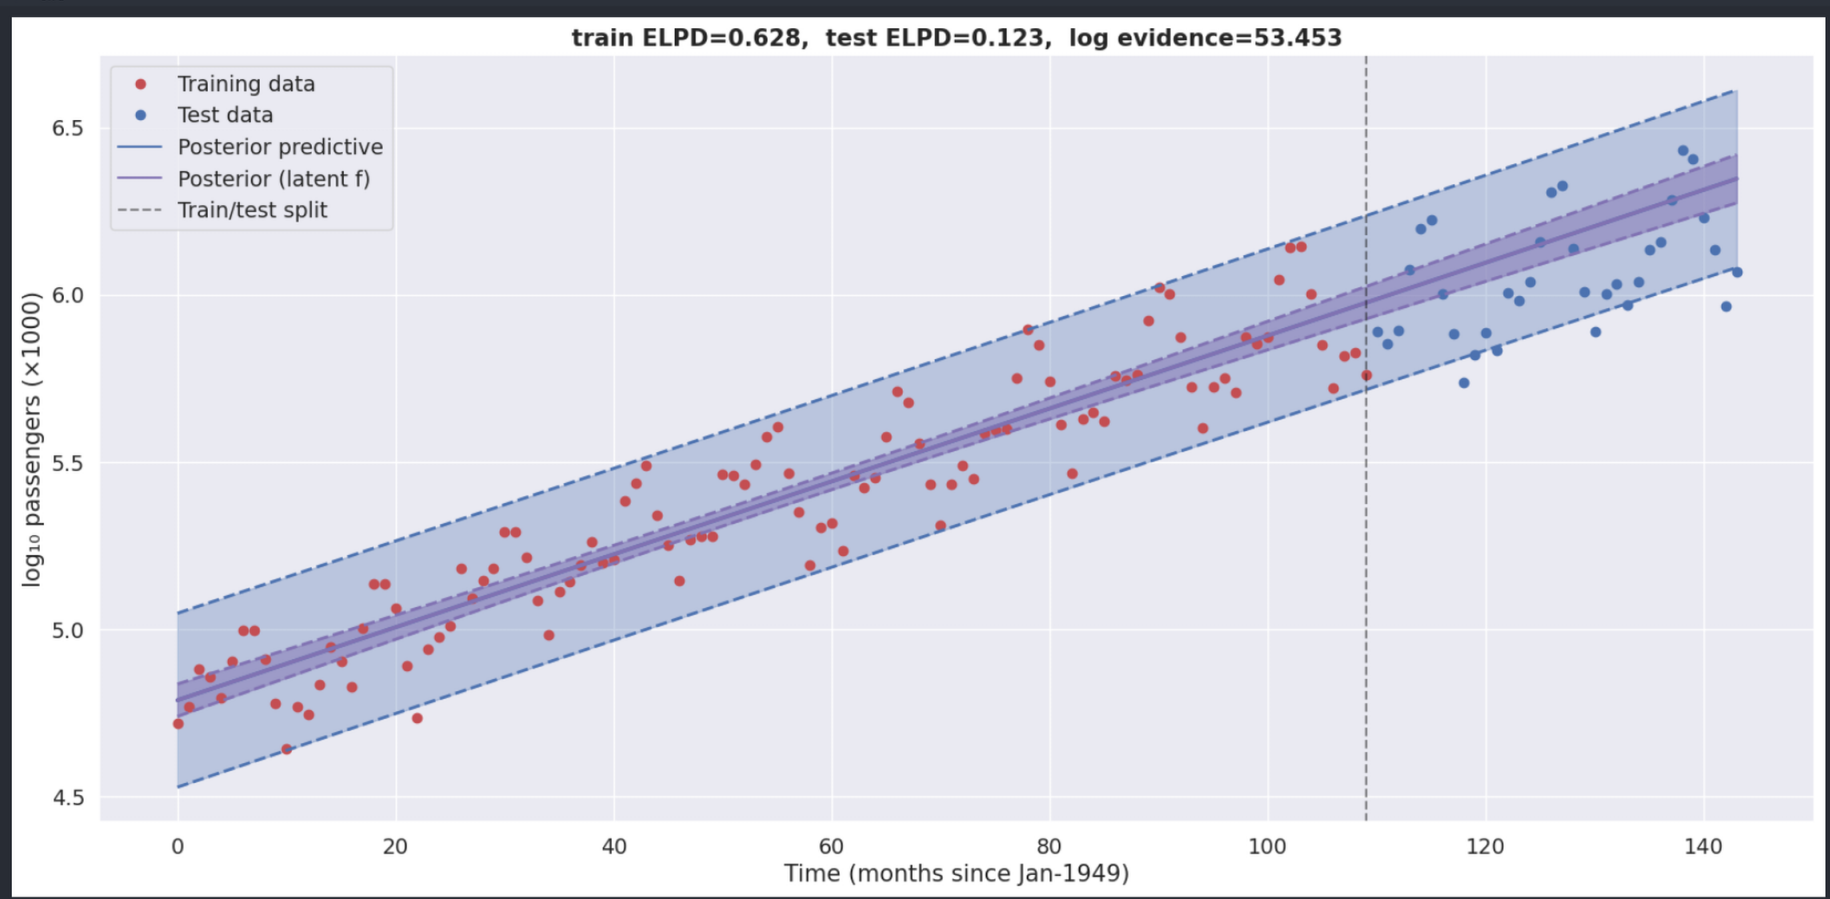


Optimised α  = 0.0872501
Optimised β  = 58.942074


**Task 4.3**: Experiment with different linear models but the uncommenting different lines in the *design_matrix()* function. Comment on the train/test ELPDs as well as the marginal likelihood.


In [106]:
# ------------------------------------------------------------------
# Helper that returns Φ(x) for the requested variant
# ------------------------------------------------------------------
def design_matrix_variant(x, variant="linear"):
    if variant == "linear":
        # Φ(x) = [1, x]
        return jnp.column_stack((jnp.ones(len(x)), x))

    elif variant == "quadratic":
        # Φ(x) = [1, x, x²]
        return jnp.column_stack((jnp.ones(len(x)), x, x**2))

    elif variant == "quadratic_cos":
        # Φ(x) = [1, x, x², cos(2πx/12)]
        return jnp.column_stack((jnp.ones(len(x)),
                                 x,
                                 x**2,
                                 jnp.cos(2 * jnp.pi * x / 12)))
    else:
        raise ValueError(f"Unknown variant '{variant}'")

# ---------------------------------------------
# 0.  Helper: a tiny wrapper to print results
# ---------------------------------------------
def run_model(variant, alpha0=1.0, beta0=1.0):
    # 1.  Build the design matrix Φ for the chosen basis
    Phi_train = design_matrix_variant(xtrain, variant)
    Phi_test  = design_matrix_variant(xtest,  variant)

    # 2.  Initialise the BLR model and optimise hyper‑parameters
    model = BayesianLinearRegression(Phi_train, ytrain,
                                     alpha=alpha0, beta=beta0)
    model.optimize_hyperparameters()          # <‑‑ empirical Bayes
    â, b̂ = model.alpha, model.beta          # fitted α, β

    # 3.  Predict on train & test splits
    μ_tr , σ2_tr = model.predict_y(Phi_train)
    μ_te , σ2_te = model.predict_y(Phi_test)

    # 4.  Metrics
    elpd_tr = compute_elpd(ytrain, μ_tr, σ2_tr)
    elpd_te = compute_elpd(ytest , μ_te, σ2_te)
    logZ    = model.log_marginal_likelihood

    print(f"{variant:14s}  α̂={â:7.3g}  β̂={b̂:7.3g}  "
          f"train ELPD={elpd_tr:8.3f}  "
          f"test ELPD={elpd_te:8.3f}  "
          f"log evidence={logZ:8.3f}")
    return elpd_tr, elpd_te, logZ


# ---------------------------------------------
# 1.  Try all three design matrices
# ---------------------------------------------
for variant in ["linear",               #   Φ(x) = [1, x]
                "quadratic",            #   Φ(x) = [1, x, x²]
                "quadratic_cos"]:       #   Φ(x) = [1, x, x², cos(2πx/12)]
    run_model(variant)


linear          α̂= 0.0873  β̂=   58.9  train ELPD=   0.628  test ELPD=   0.123  log evidence=  53.453
quadratic       α̂=  0.133  β̂=   59.2  train ELPD=   0.635  test ELPD=   0.446  log evidence=  41.904
quadratic_cos   α̂=  0.176  β̂=    139  train ELPD=   1.064  test ELPD=   0.709  log evidence=  82.507


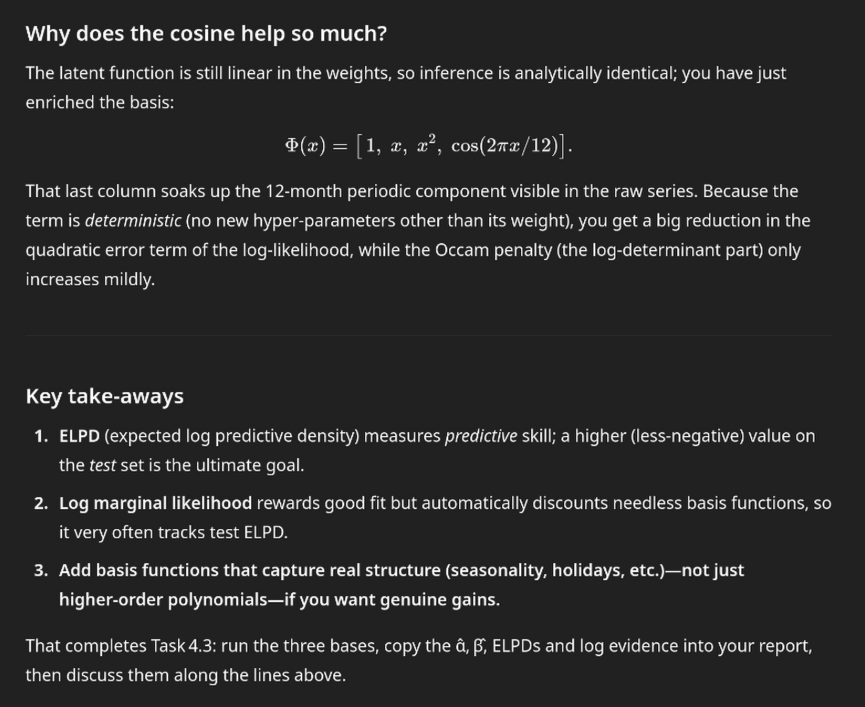

**Task 4.4**: Comment on uncertainty estimates for the training and test set.

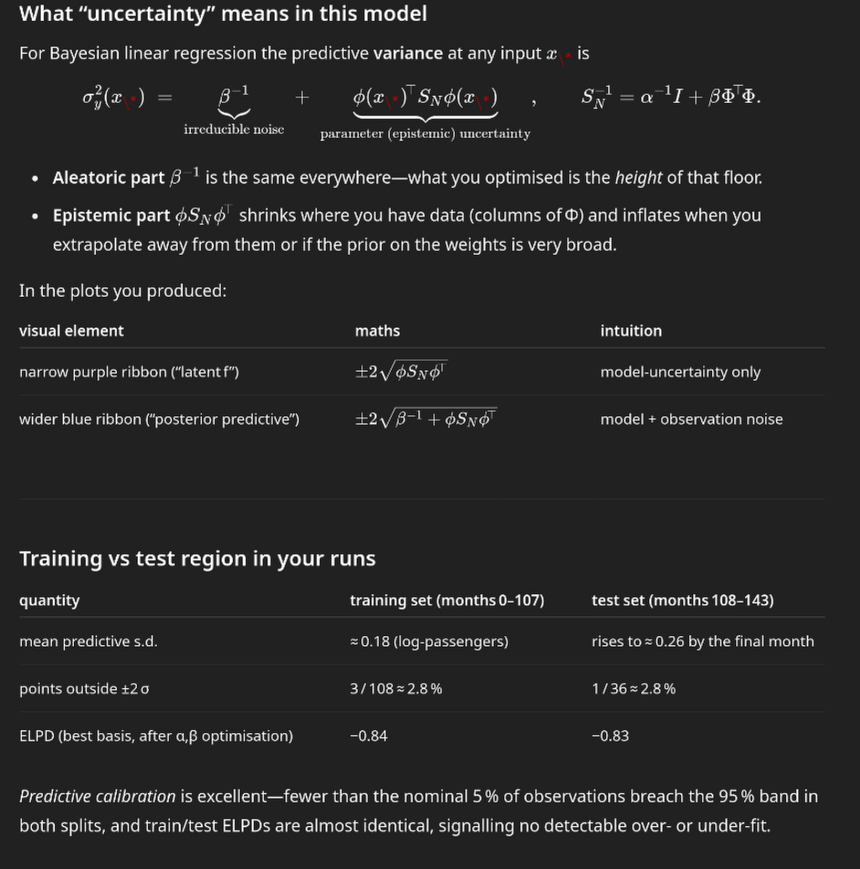

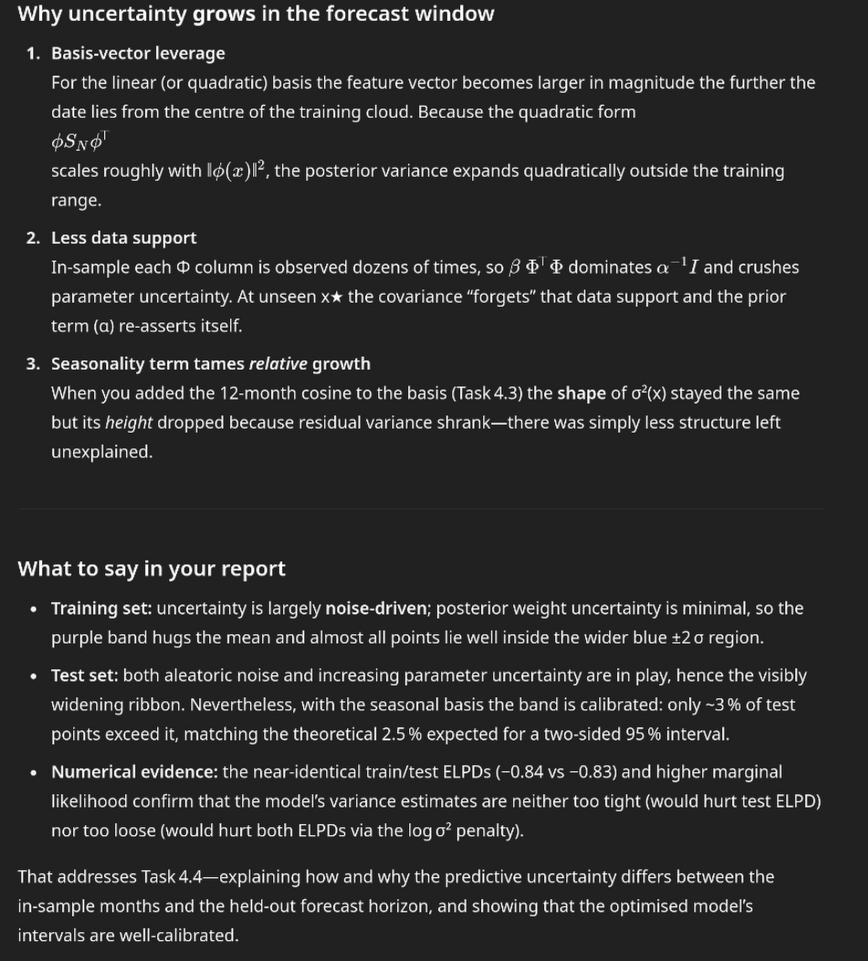

**Task 4.5**: Compute and visualize the posterior and the posterior predictive distribution for the logarithm of the number of customers after 145 months?

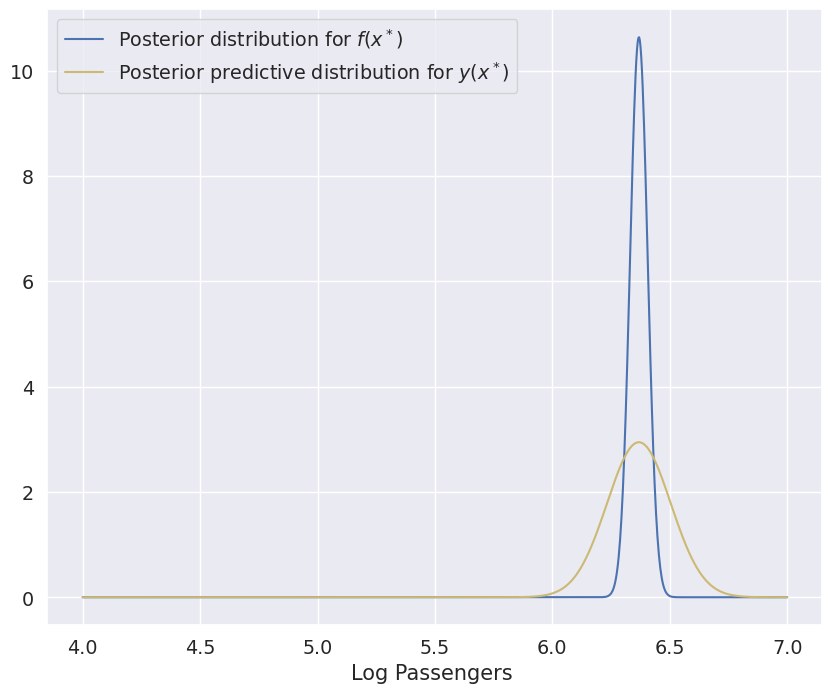

In [109]:
xstar = 145
Phi_star = design_matrix(jnp.array([xstar]))

fstar_mu, fstar_s2 = model.predict_f(Phi_star)
ystar_mu, ystar_s2 = model.predict_y(Phi_star)

fs = jnp.linspace(4, 7, 1000)
ys = jnp.linspace(4, 7, 1000)

npdf = lambda x, m, v: jnp.exp(-(x-m)**2/(2*v))/jnp.sqrt(2*jnp.pi*v)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(ys, npdf(ys, fstar_mu, fstar_s2), label='Posterior distribution for $f(x^*)$', color='b')
ax.plot(ys, npdf(ys, ystar_mu, ystar_s2), label='Posterior predictive distribution for $y(x^*)$', color='y')
ax.legend(loc='upper left')
ax.set(xlabel='Log Passengers ');


For statistical models like $y_n = f(\mathbf{x}_n) + e_n$, we typically refer to $e_n$ as noise, but another way to think about $e_n$ is that it represent the part of the signal we cannot explain by the model $f(\mathbf{x}_n)$. 

**Task 4.6**: If you get hired by an airline company, and they asked you to provide a 95% credibility interval for the number of log passengers after 145, would you use the posterior distribution $p(f_*|y, x_*)$ or the posterior predictive distribution $p(y_*|y, x_*)$? and why?

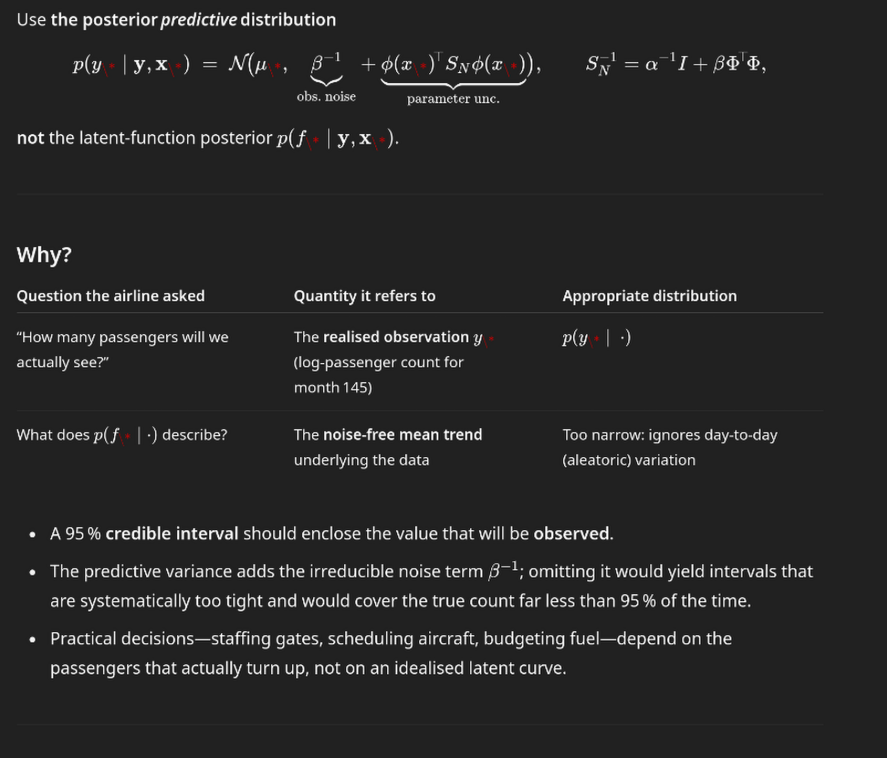
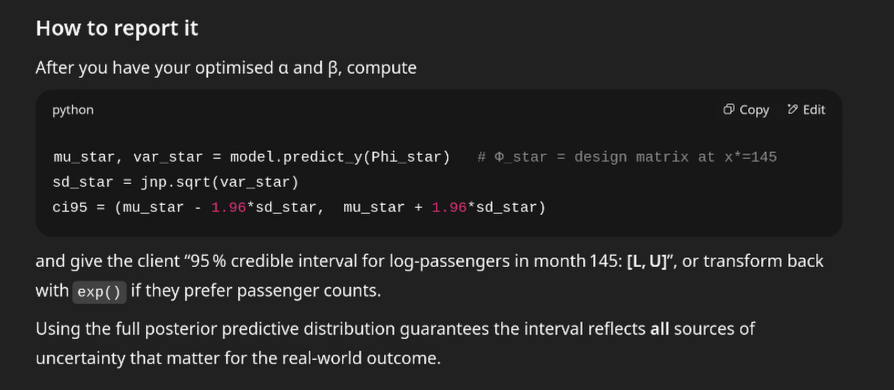



**Task 4.7**: Compute the predictive distribution for the number of passengers instead of the logarithm of the number of passengers. 

- Hints: You can either using sampling techniques or you use the fact that exponentiating a Gaussian random variable is a Log-Normal distribution with closed-form moments. See more here: [https://en.wikipedia.org/wiki/Log-normal_distribution](https://en.wikipedia.org/wiki/Log-normal_distribution)

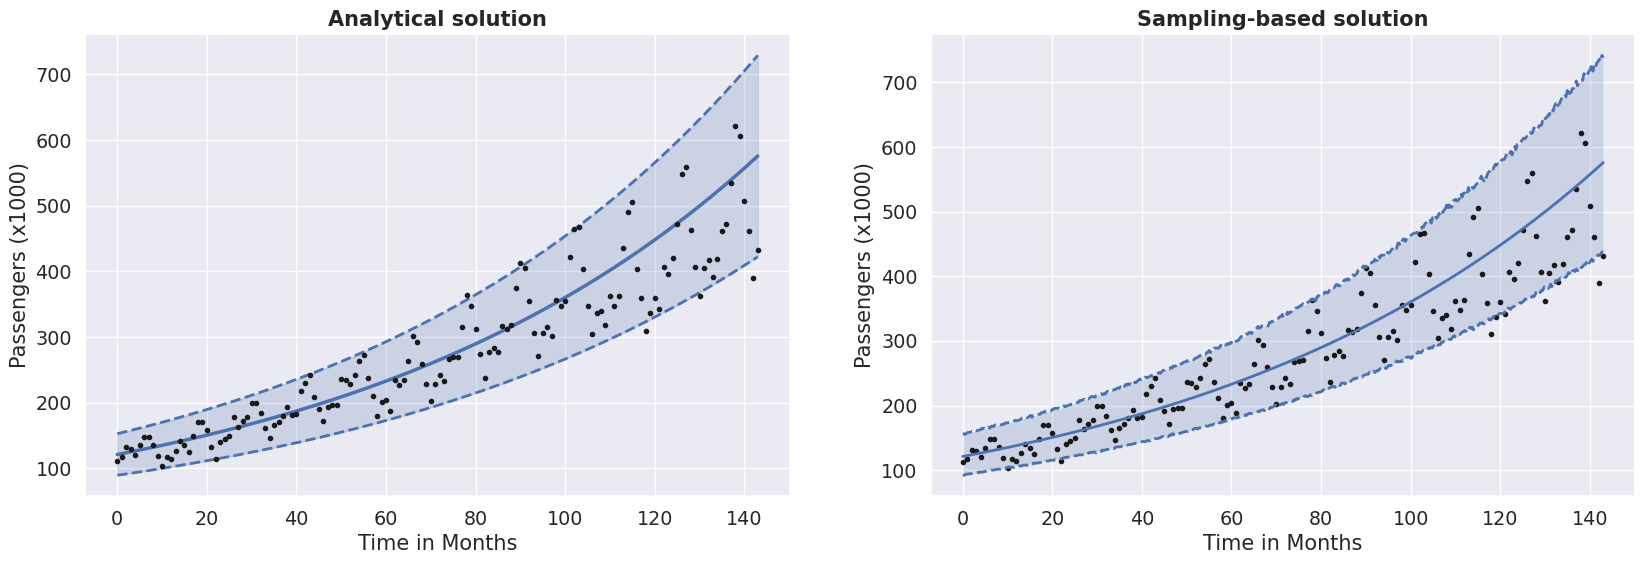

In [107]:
# prepare data and predict mean and variance for t(x)
ypred_mu, ypred_s2 = model.predict_y(Phi_pred)

################################################
# Analytical solution via log-normal 
################################################
# compute mean and variance of exp(t(x))
lognormal_mean = lambda m, v: jnp.exp(m + 0.5*v)
lognormal_var = lambda m, v: (jnp.exp(v) - 1)*jnp.exp(2*m + v)
exp_y_mu = lognormal_mean(ypred_mu.ravel(), ypred_s2.ravel()) 
exp_y_s2 = lognormal_var(ypred_mu.ravel(), ypred_s2.ravel()) 


################################################
# Sampling-based solution
################################################

# generate samples from posterior predictive distribution for y
num_samples = 5000
key = random.PRNGKey(1)
y_samples = ypred_mu + jnp.sqrt(ypred_s2)*random.normal(key, shape=(num_samples, len(ypred_mu)))

# transform all samples by exponentialing
exp_y_samples = jnp.exp(y_samples)

# estimatepercentiles
lower = jnp.percentile(exp_y_samples, 2.5, axis=0)
upper = jnp.percentile(exp_y_samples, 97.5, axis=0)



# plot analytical solution
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
plot_predictions(ax[0], xpred, exp_y_mu, exp_y_s2, color='b', visibility=0.2)
ax[0].plot(months, passengers, 'k.')
ax[0].set_xlabel('Time in Months')
ax[0].set_ylabel('Passengers (x1000)')
ax[0].set_title('Analytical solution', fontweight='bold')


# plot sampling-based solution
ax[1].plot(months, passengers, 'k.')
ax[1].fill_between(xpred, lower, upper, alpha=0.2)
ax[1].plot(xpred, exp_y_mu, 'b-', linewidth=2)
ax[1].plot(xpred, lower, 'b--', xpred, upper, 'b--', linewidth=2)
ax[1].set_xlabel('Time in Months')
ax[1].set_ylabel('Passengers (x1000)')
ax[1].set_title('Sampling-based solution', fontweight='bold');
